In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warning messages to keep output clean
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Load the Seoul Bike Sharing Dataset
# ============================================================

# Load the dataset
df = pd.read_csv("SeoulBikeData.csv", encoding="latin1")

# Display first five rows
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
# ============================================================
#  Checking Dataset Shape and Column Names
# ============================================================

# Check number of rows and columns
print("Dataset shape:", df.shape)

# Display all column names
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (8760, 14)

Column names:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


In [4]:
# ============================================================
#  Check Dataset Information
# ============================================================

# Display data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [5]:
# ============================================================
#   Summary Statistics of Numerical Columns
# ============================================================

# Show statistical summary
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [6]:
# ============================================================
#   Clean Column Names
# ============================================================

# Removing extra spaces and replace spaces/symbols with underscores
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)
df.columns = df.columns.str.replace("/", "_", regex=False)

# Displaying updated column names
print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['Date', 'Rented_Bike_Count', 'Hour', 'Temperature°C', 'Humidity%', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperature°C', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day']


In [7]:
# ============================================================
#  Check Missing Values
# ============================================================

# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Date                       0
Rented_Bike_Count          0
Hour                       0
Temperature°C              0
Humidity%                  0
Wind_speed_m_s             0
Visibility_10m             0
Dew_point_temperature°C    0
Solar_Radiation_MJ_m2      0
Rainfallmm                 0
Snowfall_cm                0
Seasons                    0
Holiday                    0
Functioning_Day            0
dtype: int64


In [8]:
# ============================================================
#   Check Duplicate Rows
# ============================================================

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
# ============================================================
#   9: Remove Duplicate Rows
# ============================================================

# Remove duplicate rows if present
df = df.drop_duplicates()

# Check new dataset shape
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (8760, 14)


In [10]:
# ============================================================
#  Identify Categorical Columns
# ============================================================

# Select columns with object datatype
categorical_columns = df.select_dtypes(include=["object"]).columns

# Display categorical columns
print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Date', 'Seasons', 'Holiday', 'Functioning_Day']


In [11]:
# ============================================================
#  Check Unique Values in Categorical Columns
# ============================================================

# Display unique values in each categorical column
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in Date:
['01/12/2017' '02/12/2017' '03/12/2017' '04/12/2017' '05/12/2017'
 '06/12/2017' '07/12/2017' '08/12/2017' '09/12/2017' '10/12/2017'
 '11/12/2017' '12/12/2017' '13/12/2017' '14/12/2017' '15/12/2017'
 '16/12/2017' '17/12/2017' '18/12/2017' '19/12/2017' '20/12/2017'
 '21/12/2017' '22/12/2017' '23/12/2017' '24/12/2017' '25/12/2017'
 '26/12/2017' '27/12/2017' '28/12/2017' '29/12/2017' '30/12/2017'
 '31/12/2017' '01/01/2018' '02/01/2018' '03/01/2018' '04/01/2018'
 '05/01/2018' '06/01/2018' '07/01/2018' '08/01/2018' '09/01/2018'
 '10/01/2018' '11/01/2018' '12/01/2018' '13/01/2018' '14/01/2018'
 '15/01/2018' '16/01/2018' '17/01/2018' '18/01/2018' '19/01/2018'
 '20/01/2018' '21/01/2018' '22/01/2018' '23/01/2018' '24/01/2018'
 '25/01/2018' '26/01/2018' '27/01/2018' '28/01/2018' '29/01/2018'
 '30/01/2018' '31/01/2018' '01/02/2018' '02/02/2018' '03/02/2018'
 '04/02/2018' '05/02/2018' '06/02/2018' '07/02/2018' '08/02/2018'
 '09/02/2018' '10/02/2018' '11/02/2018' '12/02/2018'

In [12]:
# ============================================================
# Convert Date Column to Datetime Format
# ============================================================

# Convert Date column from object/text format into datetime format
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

# Check the updated datatype of Date column
print("Date column datatype after conversion:")
print(df["Date"].dtype)

# Display first five date values
df["Date"].head()

Date column datatype after conversion:
datetime64[ns]


,Date
0,2017-12-01
1,2017-12-01
2,2017-12-01
3,2017-12-01
4,2017-12-01


In [13]:
# ============================================================
#  Create New Date-Based Features
# ============================================================

# Extract day from Date
df["Day"] = df["Date"].dt.day

# Extract month from Date
df["Month"] = df["Date"].dt.month

# Extract weekday from Date
# Monday = 0, Tuesday = 1, ..., Sunday = 6
df["Weekday"] = df["Date"].dt.weekday

# Display the new date-based features
df[["Date", "Day", "Month", "Weekday"]].head()

,Date,Day,Month,Weekday
0,2017-12-01,1,12,4
1,2017-12-01,1,12,4
2,2017-12-01,1,12,4
3,2017-12-01,1,12,4
4,2017-12-01,1,12,4


In [14]:
# ============================================================
#  Drop Original Date Column
# ============================================================

# Drop the original Date column because useful features are already extracted
df = df.drop("Date", axis=1)

# Display updated columns
print("Columns after dropping Date:")
print(df.columns.tolist())

Columns after dropping Date:
['Rented_Bike_Count', 'Hour', 'Temperature°C', 'Humidity%', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperature°C', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day', 'Day', 'Month', 'Weekday']


In [15]:
# ============================================================
# Check Remaining Categorical Columns
# ============================================================

# Check remaining categorical columns after dropping Date
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Remaining categorical columns:")
print(categorical_columns.tolist())

Remaining categorical columns:
['Seasons', 'Holiday', 'Functioning_Day']


In [16]:
# ============================================================
# Encode Categorical Variables
# ============================================================

# Convert categorical variables into numerical format
df = pd.get_dummies(
    df,
    columns=["Seasons", "Holiday", "Functioning_Day"],
    drop_first=True
)

# Displaying first five rows
df.head()

,Rented_Bike_Count,Hour,Temperature°C,Humidity%,Wind_speed_m_s,Visibility_10m,Dew_point_temperature°C,Solar_Radiation_MJ_m2,Rainfallmm,Snowfall_cm,Day,Month,Weekday,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,12,4,False,False,True,True,True
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,12,4,False,False,True,True,True
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,12,4,False,False,True,True,True
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,12,4,False,False,True,True,True
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,12,4,False,False,True,True,True


In [17]:
# ============================================================
# Convert Boolean Columns to Integer
# ============================================================

# Convert boolean columns into integer values 0 and 1
bool_columns = df.select_dtypes(include=["bool"]).columns

df[bool_columns] = df[bool_columns].astype(int)

print("Boolean columns converted to integers:")
print(bool_columns.tolist())

# Displaying first five rows
df.head()

Boolean columns converted to integers:
['Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter', 'Holiday_No Holiday', 'Functioning_Day_Yes']


,Rented_Bike_Count,Hour,Temperature°C,Humidity%,Wind_speed_m_s,Visibility_10m,Dew_point_temperature°C,Solar_Radiation_MJ_m2,Rainfallmm,Snowfall_cm,Day,Month,Weekday,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,12,4,0,0,1,1,1
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1


In [18]:
# ============================================================
# Final Dataset Information After Encoding
# ============================================================

# Checking final dataset shape
print("Final dataset shape:", df.shape)

# final data types
df.info()

Final dataset shape: (8760, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented_Bike_Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature°C            8760 non-null   float64
 3   Humidity%                8760 non-null   int64  
 4   Wind_speed_m_s           8760 non-null   float64
 5   Visibility_10m           8760 non-null   int64  
 6   Dew_point_temperature°C  8760 non-null   float64
 7   Solar_Radiation_MJ_m2    8760 non-null   float64
 8   Rainfallmm               8760 non-null   float64
 9   Snowfall_cm              8760 non-null   float64
 10  Day                      8760 non-null   int32  
 11  Month                    8760 non-null   int32  
 12  Weekday                  8760 non-null   int32  
 13  Seasons_Spring           8760 non-null   int64

In [19]:
# ============================================================
# Final Missing Value Check
# ============================================================

# Checking missing values after preprocessing
print("Final missing values:")
print(df.isnull().sum())

Final missing values:
Rented_Bike_Count          0
Hour                       0
Temperature°C              0
Humidity%                  0
Wind_speed_m_s             0
Visibility_10m             0
Dew_point_temperature°C    0
Solar_Radiation_MJ_m2      0
Rainfallmm                 0
Snowfall_cm                0
Day                        0
Month                      0
Weekday                    0
Seasons_Spring             0
Seasons_Summer             0
Seasons_Winter             0
Holiday_No Holiday         0
Functioning_Day_Yes        0
dtype: int64


In [20]:
# ============================================================
# Separate Features and Target Variable
# ============================================================

# Defining target variable
target = "Rented_Bike_Count"

# X contains independent/input features
X = df.drop(target, axis=1)

# y contains dependent/target variable
y = df[target]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (8760, 17)
Target dataset shape: (8760,)


In [21]:
# ============================================================
#Preprocessed Dataset
# ============================================================

df.to_csv("preprocessed_seoul_bike_data.csv", index=False)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


In [22]:
# ============================================================
# Downloading the Preprocessed Dataset
# ============================================================

from google.colab import files

files.download("preprocessed_seoul_bike_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# ============================================================
#  Cleaning Encoded Column Names
# ============================================================

# Cleaning all column names again after categorical encoding
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_", regex=False)
)

print("Final cleaned column names:")
print(df.columns.tolist())

Final cleaned column names:
['Rented_Bike_Count', 'Hour', 'Temperature°C', 'Humidity%', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperature°C', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Day', 'Month', 'Weekday', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter', 'Holiday_No_Holiday', 'Functioning_Day_Yes']


In [24]:

# Creating a weekend indicator
# Saturday = 5 and Sunday = 6
df["Is_Weekend"] = (df["Weekday"] >= 5).astype(int)

# Creating a peak-hour indicator

peak_hours = [7, 8, 9, 17, 18, 19]
df["Is_Peak_Hour"] = df["Hour"].isin(peak_hours).astype(int)

# newly created features
df[["Hour", "Weekday", "Is_Weekend", "Is_Peak_Hour"]].head(10)

,Hour,Weekday,Is_Weekend,Is_Peak_Hour
0,0,4,0,0
1,1,4,0,0
2,2,4,0,0
3,3,4,0,0
4,4,4,0,0
5,5,4,0,0
6,6,4,0,0
7,7,4,0,1
8,8,4,0,1
9,9,4,0,1


In [25]:
# ============================================================
#   Checking New Feature Distributions
# ============================================================

print("Weekend value counts:")
print(df["Is_Weekend"].value_counts())

print("\nPeak-hour value counts:")
print(df["Is_Peak_Hour"].value_counts())

Weekend value counts:
Is_Weekend
0    6264
1    2496
Name: count, dtype: int64

Peak-hour value counts:
Is_Peak_Hour
0    6570
1    2190
Name: count, dtype: int64


In [26]:
# ============================================================
# Updating Features and Target
# ============================================================

# the target variable
target = "Rented_Bike_Count"

# updated feature dataset
X = df.drop(columns=[target])

#target dataset
y = df[target]

print("Updated feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Updated feature dataset shape: (8760, 19)
Target dataset shape: (8760,)


In [27]:
# ============================================================
#  Save Updated Preprocessed Dataset
# ============================================================

# Save the dataset with the additional engineered features
df.to_csv(
    "final_preprocessed_seoul_bike_data.csv",
    index=False
)

print("Final preprocessed dataset saved successfully.")

Final preprocessed dataset saved successfully.


Exploratory Data Analysis

In [28]:
# ============================================================
#   Reloading Original Dataset for EDA
# ============================================================


eda_df = pd.read_csv(
    "SeoulBikeData.csv",
    encoding="latin1"
)

# Cleaning column names
eda_df.columns = (
    eda_df.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_", regex=False)
)

print("EDA dataset shape:", eda_df.shape)
print("\nEDA dataset columns:")
print(eda_df.columns.tolist())

EDA dataset shape: (8760, 14)

EDA dataset columns:
['Date', 'Rented_Bike_Count', 'Hour', 'Temperature°C', 'Humidity%', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperature°C', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day']


In [29]:
# ============================================================
#  Creating Date-Based Features for EDA
# ============================================================

# Converting Date column into datetime format
eda_df["Date"] = pd.to_datetime(
    eda_df["Date"],
    format="%d/%m/%Y"
)

# Extracting useful calendar features
eda_df["Month"] = eda_df["Date"].dt.month
eda_df["Weekday_Number"] = eda_df["Date"].dt.weekday
eda_df["Weekday_Name"] = eda_df["Date"].dt.day_name()

# Creating weekday/weekend category
eda_df["Day_Type"] = np.where(
    eda_df["Weekday_Number"] >= 5,
    "Weekend",
    "Weekday"
)

# Creating peak-hour category
peak_hours = [7, 8, 9, 17, 18, 19]

eda_df["Hour_Type"] = np.where(
    eda_df["Hour"].isin(peak_hours),
    "Peak Hour",
    "Non-Peak Hour"
)

eda_df[
    [
        "Date",
        "Month",
        "Weekday_Name",
        "Day_Type",
        "Hour",
        "Hour_Type"
    ]
].head()

,Date,Month,Weekday_Name,Day_Type,Hour,Hour_Type
0,2017-12-01,12,Friday,Weekday,0,Non-Peak Hour
1,2017-12-01,12,Friday,Weekday,1,Non-Peak Hour
2,2017-12-01,12,Friday,Weekday,2,Non-Peak Hour
3,2017-12-01,12,Friday,Weekday,3,Non-Peak Hour
4,2017-12-01,12,Friday,Weekday,4,Non-Peak Hour


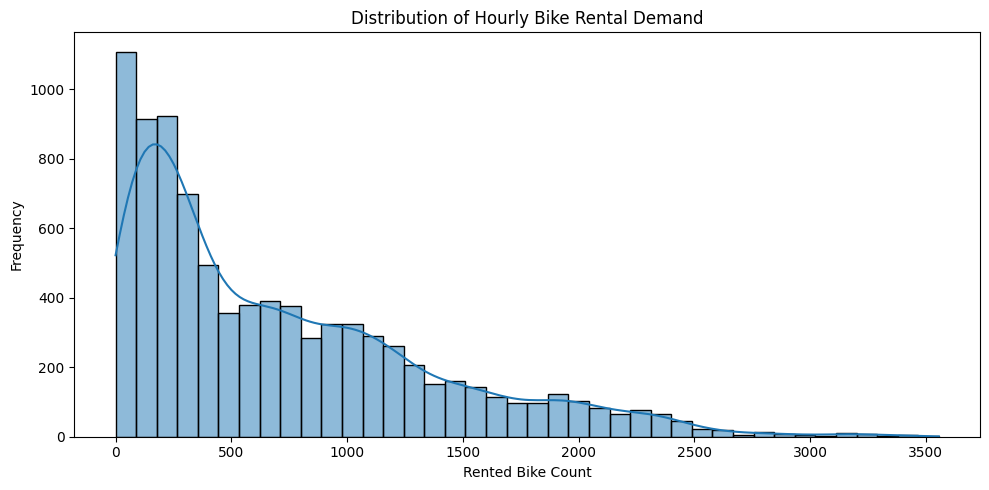

Skewness of Rented Bike Count: 1.153


In [30]:
# ============================================================
#  Distribution of Rented Bike Count
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="Rented_Bike_Count",
    bins=40,
    kde=True
)

plt.title("Distribution of Hourly Bike Rental Demand")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# numerical skewness
print(
    "Skewness of Rented Bike Count:",
    round(eda_df["Rented_Bike_Count"].skew(), 3)
)

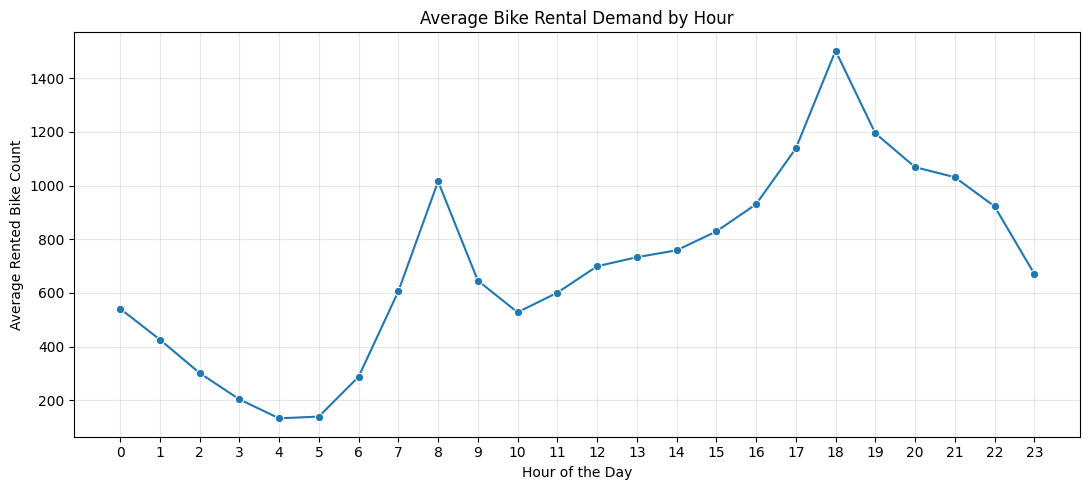

In [31]:
# ============================================================
#  Average Bike Demand by Hour
# ============================================================

hourly_demand = (
    eda_df
    .groupby("Hour")["Rented_Bike_Count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=hourly_demand,
    x="Hour",
    y="Rented_Bike_Count",
    marker="o"
)

plt.title("Average Bike Rental Demand by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Rented Bike Count")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

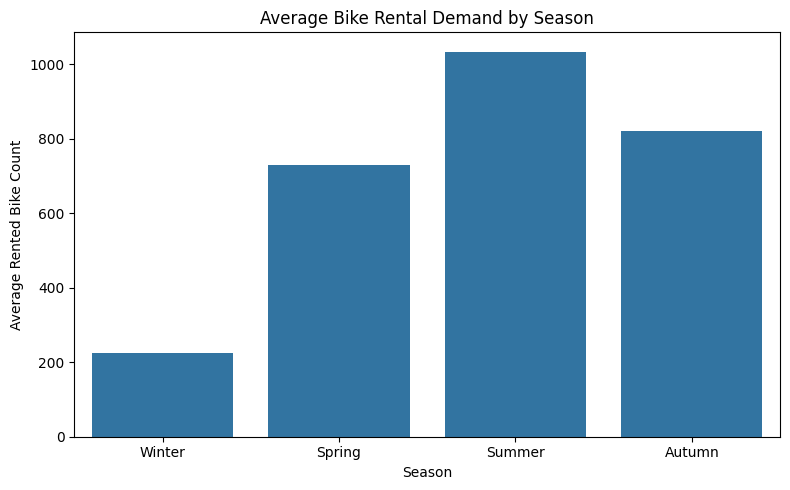

  Seasons  Rented_Bike_Count
0  Winter         225.541204
1  Spring         730.031250
2  Summer        1034.073370
3  Autumn         819.597985


In [32]:
# ============================================================
#  Average Bike Demand by Season
# ============================================================

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

seasonal_demand = (
    eda_df
    .groupby("Seasons")["Rented_Bike_Count"]
    .mean()
    .reindex(season_order)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=seasonal_demand,
    x="Seasons",
    y="Rented_Bike_Count"
)

plt.title("Average Bike Rental Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Rented Bike Count")
plt.tight_layout()
plt.show()

print(seasonal_demand)

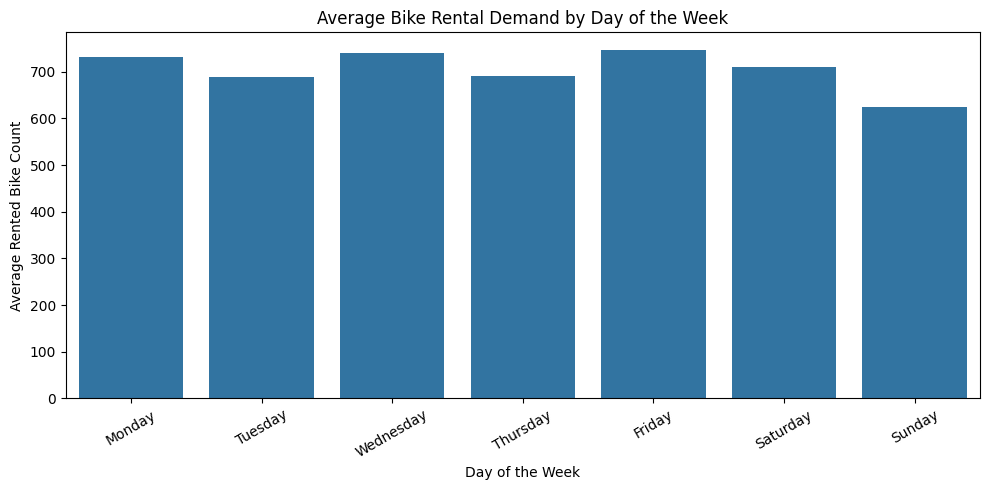

  Weekday_Name  Rented_Bike_Count
0       Monday         730.563301
1      Tuesday         687.977564
2    Wednesday         740.349359
3     Thursday         690.704327
4       Friday         747.117925
5     Saturday         709.528846
6       Sunday         625.155449


In [33]:
# ============================================================
# Average Bike Demand by Day of the Week
# ============================================================

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand = (
    eda_df
    .groupby("Weekday_Name")["Rented_Bike_Count"]
    .mean()
    .reindex(weekday_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_demand,
    x="Weekday_Name",
    y="Rented_Bike_Count"
)

plt.title("Average Bike Rental Demand by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Rented Bike Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(weekday_demand)

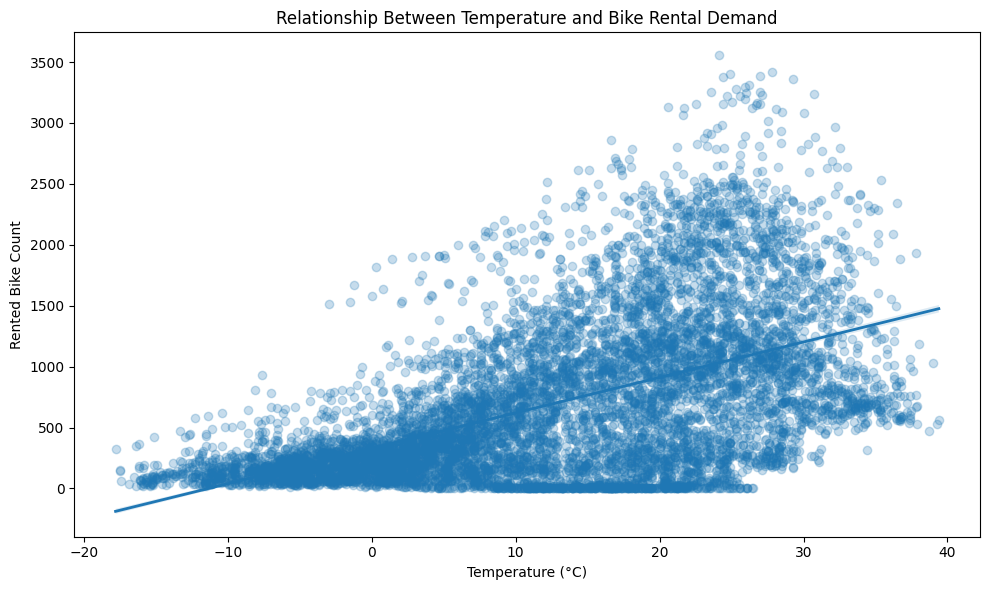

Correlation between Temperature and Bike Demand: 0.539


In [34]:
# ============================================================
#  Relationship Between Temperature and Demand
# ============================================================

plt.figure(figsize=(10, 6))

sns.regplot(
    data=eda_df,
    x="Temperature°C",
    y="Rented_Bike_Count",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between Temperature and Bike Rental Demand")
plt.xlabel("Temperature (°C)")
plt.ylabel("Rented Bike Count")
plt.tight_layout()
plt.show()

temperature_correlation = eda_df[
    ["Temperature°C", "Rented_Bike_Count"]
].corr().iloc[0, 1]

print(
    "Correlation between Temperature and Bike Demand:",
    round(temperature_correlation, 3)
)

In [35]:
# ============================================================
#   Rainfall Categories
# ============================================================

eda_df["Rainfall_Category"] = pd.cut(
    eda_df["Rainfallmm"],
    bins=[-0.01, 0, 5, 15, float("inf")],
    labels=[
        "No Rain",
        "Light Rain",
        "Moderate Rain",
        "Heavy Rain"
    ]
)

print(eda_df["Rainfall_Category"].value_counts())

Rainfall_Category
No Rain          8232
Light Rain        462
Moderate Rain      53
Heavy Rain         13
Name: count, dtype: int64


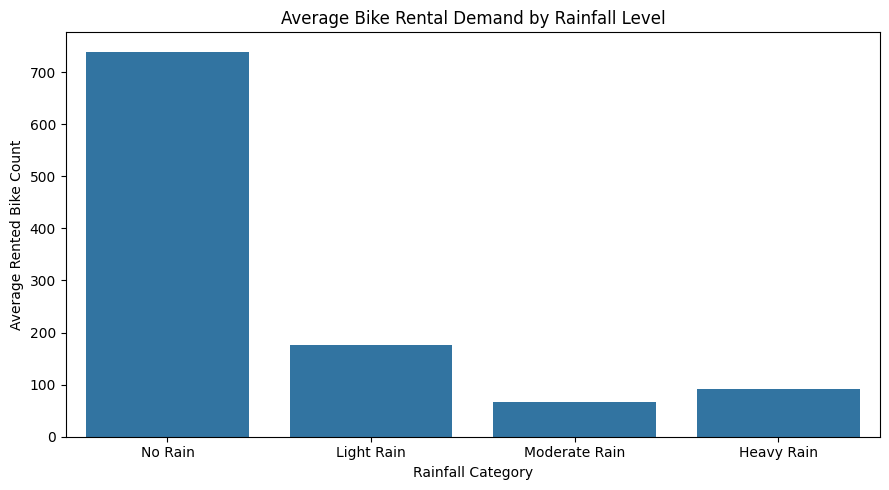

  Rainfall_Category  Rented_Bike_Count
0           No Rain         739.311103
1        Light Rain         176.655844
2     Moderate Rain          66.207547
3        Heavy Rain          90.846154


In [36]:
# ============================================================
#    Average Demand by Rainfall Category
# ============================================================

rainfall_order = [
    "No Rain",
    "Light Rain",
    "Moderate Rain",
    "Heavy Rain"
]

rainfall_demand = (
    eda_df
    .groupby(
        "Rainfall_Category",
        observed=False
    )["Rented_Bike_Count"]
    .mean()
    .reindex(rainfall_order)
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=rainfall_demand,
    x="Rainfall_Category",
    y="Rented_Bike_Count"
)

plt.title("Average Bike Rental Demand by Rainfall Level")
plt.xlabel("Rainfall Category")
plt.ylabel("Average Rented Bike Count")
plt.tight_layout()
plt.show()

print(rainfall_demand)

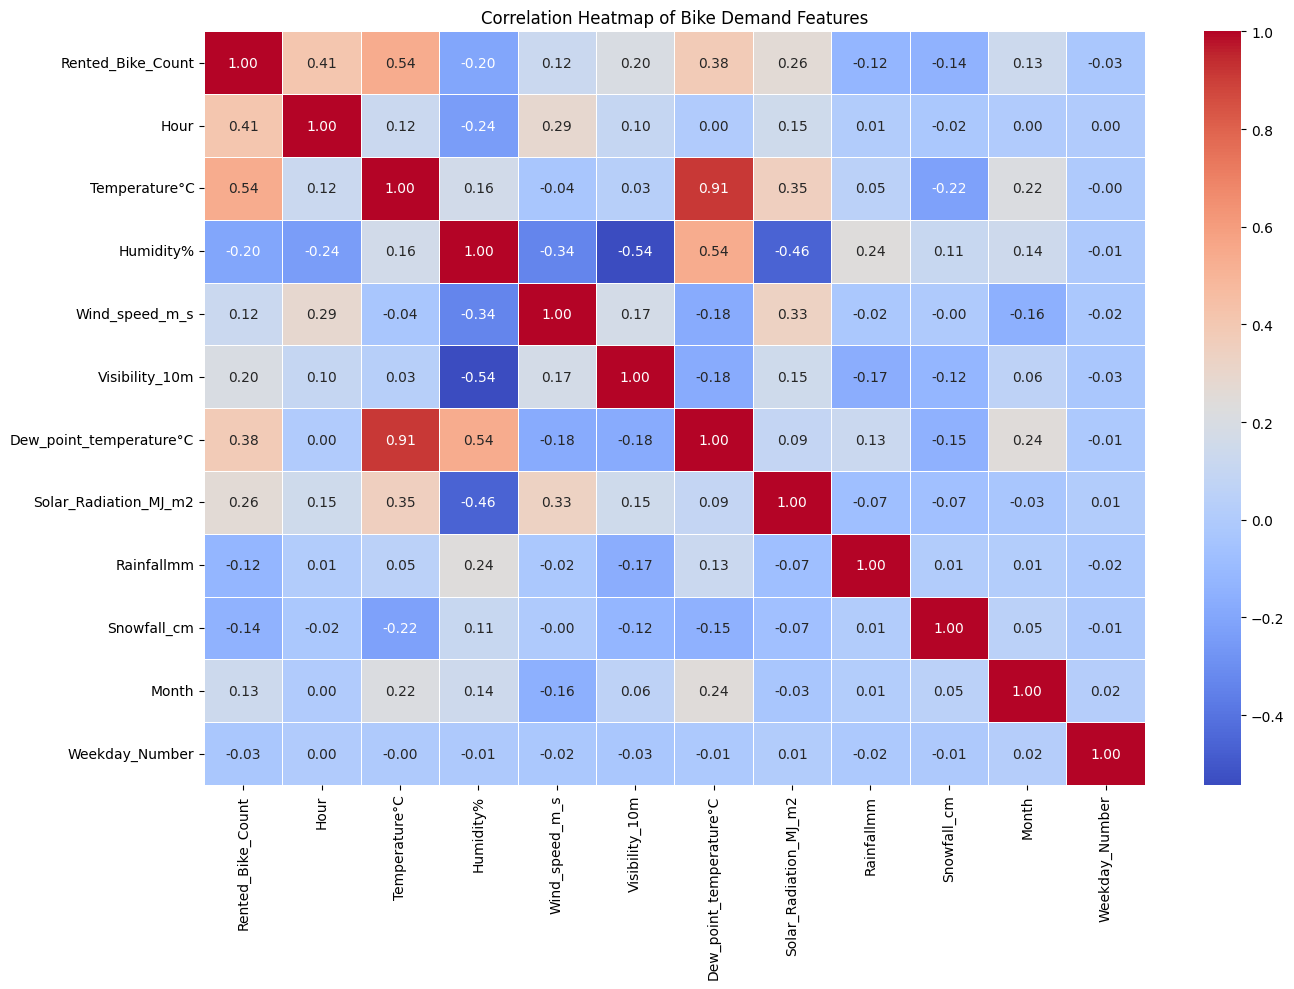

In [37]:
# ============================================================
#   Correlation Heatmap
# ============================================================

# Selecting numerical columns
numerical_columns = [
    "Rented_Bike_Count",
    "Hour",
    "Temperature°C",
    "Humidity%",
    "Wind_speed_m_s",
    "Visibility_10m",
    "Dew_point_temperature°C",
    "Solar_Radiation_MJ_m2",
    "Rainfallmm",
    "Snowfall_cm",
    "Month",
    "Weekday_Number"
]

#correlation matrix
correlation_matrix = eda_df[numerical_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Bike Demand Features")
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# Ranking Features by Correlation with Target
# ============================================================

feature_correlations = (
    correlation_matrix["Rented_Bike_Count"]
    .drop("Rented_Bike_Count")
    .sort_values(ascending=False)
)

print("Numerical features ranked by correlation with bike demand:")
print(feature_correlations)

Numerical features ranked by correlation with bike demand:
Temperature°C              0.538558
Hour                       0.410257
Dew_point_temperature°C    0.379788
Solar_Radiation_MJ_m2      0.261837
Visibility_10m             0.199280
Month                      0.133514
Wind_speed_m_s             0.121108
Weekday_Number            -0.029357
Rainfallmm                -0.123074
Snowfall_cm               -0.141804
Humidity%                 -0.199780
Name: Rented_Bike_Count, dtype: float64


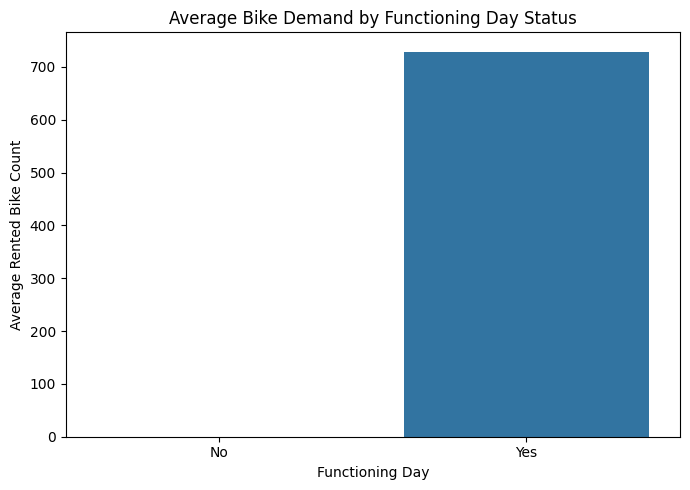

  Functioning_Day  Rented_Bike_Count
0              No           0.000000
1             Yes         729.156999


In [39]:
# ============================================================
#  Demand by Functioning Day
# ============================================================

functioning_demand = (
    eda_df
    .groupby("Functioning_Day")["Rented_Bike_Count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=functioning_demand,
    x="Functioning_Day",
    y="Rented_Bike_Count"
)

plt.title("Average Bike Demand by Functioning Day Status")
plt.xlabel("Functioning Day")
plt.ylabel("Average Rented Bike Count")
plt.tight_layout()
plt.show()

print(functioning_demand)

In [40]:
# ============================================================
# Load Final Preprocessed Seoul Bike Dataset
# ===========================================================

# Loading the final preprocessed dataset
model_df = pd.read_csv("final_preprocessed_seoul_bike_data.csv")

# Display dataset shape
print("Modelling dataset shape:", model_df.shape)


model_df.head()

Modelling dataset shape: (8760, 20)


,Rented_Bike_Count,Hour,Temperature°C,Humidity%,Wind_speed_m_s,Visibility_10m,Dew_point_temperature°C,Solar_Radiation_MJ_m2,Rainfallmm,Snowfall_cm,Day,Month,Weekday,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No_Holiday,Functioning_Day_Yes,Is_Weekend,Is_Peak_Hour
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1,0,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1,0,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,12,4,0,0,1,1,1,0,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1,0,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1,0,0


In [41]:
# ============================================================
# Clean Final Column Names for Modelling
# ============================================================

# Cleaning special characters from column names
model_df.columns = (
    model_df.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("%", "", regex=False)
    .str.replace("°", "", regex=False)
)

print("Final modelling column names:")
print(model_df.columns.tolist())

Final modelling column names:
['Rented_Bike_Count', 'Hour', 'TemperatureC', 'Humidity', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperatureC', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Day', 'Month', 'Weekday', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter', 'Holiday_No_Holiday', 'Functioning_Day_Yes', 'Is_Weekend', 'Is_Peak_Hour']


In [42]:
# ============================================================
# Separate Features and Target Variable
# ============================================================

# Defining the target variable
target = "Rented_Bike_Count"

# X contains all input features
X = model_df.drop(columns=[target])

# y contains the values to predict
y = model_df[target]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (8760, 19)
Target dataset shape: (8760,)


In [43]:
# ============================================================
# Split Data into Training and Testing Sets
# ============================================================

# Importing train_test_split
from sklearn.model_selection import train_test_split

# Splitting the dataset into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shapes of training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7008, 19)
X_test shape: (1752, 19)
y_train shape: (7008,)
y_test shape: (1752,)


In [44]:
# ============================================================
# Feature Scaling for Linear Regression
# ============================================================

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled training data shape: (7008, 19)
Scaled testing data shape: (1752, 19)


In [45]:
# ============================================================
# Create Model Evaluation Function
# ============================================================

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_regression_model(model_name, y_true, y_pred):
    """
    This function evaluates regression model performance using:
    MAE, RMSE and R2 Score.
    """

    #  negative predictions are changed to zero
    y_pred = np.maximum(y_pred, 0)

    # Calculating evaluation metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # results as a dictionary
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

print("Evaluation function created successfully.")

Evaluation function created successfully.


In [46]:
# ============================================================
#  Train Linear Regression Model
# ============================================================

# Import Linear Regression
from sklearn.linear_model import LinearRegression

#  Linear Regression model
linear_model = LinearRegression()

# Training the model using scaled training data
linear_model.fit(X_train_scaled, y_train)

# Predict on scaled testing data
linear_predictions = linear_model.predict(X_test_scaled)

# Evaluating Linear Regression model
linear_results = evaluate_regression_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

print("Linear Regression Results:")
print(linear_results)

Linear Regression Results:
{'Model': 'Linear Regression', 'MAE': 286.7011986599301, 'RMSE': np.float64(389.80856770172386), 'R2 Score': 0.6353003922718676}


In [47]:
# ============================================================
# Train Random Forest Model
# ============================================================

# Importing Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Creating Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Training the model using original training data
rf_model.fit(X_train, y_train)

# Predicting on testing data
rf_predictions = rf_model.predict(X_test)

# Evaluating Random Forest model
rf_results = evaluate_regression_model(
    "Random Forest",
    y_test,
    rf_predictions
)

print("Random Forest Results:")
print(rf_results)

Random Forest Results:
{'Model': 'Random Forest', 'MAE': 98.40491723744292, 'RMSE': np.float64(173.62004608129206), 'R2 Score': 0.9276510438038224}


In [48]:
# ============================================================
#  Train Gradient Boosting Model
# ============================================================

# Import Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Training the model using original training data
gb_model.fit(X_train, y_train)

# Predicting on testing data
gb_predictions = gb_model.predict(X_test)

# Evaluating Gradient Boosting model
gb_results = evaluate_regression_model(
    "Gradient Boosting",
    y_test,
    gb_predictions
)

print("Gradient Boosting Results:")
print(gb_results)

Gradient Boosting Results:
{'Model': 'Gradient Boosting', 'MAE': 142.33424674181433, 'RMSE': np.float64(225.48819787137123), 'R2 Score': 0.877966191033125}


In [49]:
# ============================================================
# Train XGBoost Model
# ============================================================

# Install XGBoost if needed
!pip install -q xgboost

# Import XGBoost Regressor
from xgboost import XGBRegressor

# Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Training the model using original training data
xgb_model.fit(X_train, y_train)

# Predicting on testing data
xgb_predictions = xgb_model.predict(X_test)

# Evaluating XGBoost model
xgb_results = evaluate_regression_model(
    "XGBoost",
    y_test,
    xgb_predictions
)

print("XGBoost Results:")
print(xgb_results)

XGBoost Results:
{'Model': 'XGBoost', 'MAE': 94.53492736816406, 'RMSE': np.float64(161.00563484898595), 'R2 Score': 0.9377821683883667}


In [50]:
# ============================================================
# Model Performance Comparison Table
# ============================================================

# Combining all model results into one table
results_df = pd.DataFrame([
    linear_results,
    rf_results,
    gb_results,
    xgb_results
])

# Rounding values for better readability
results_df = results_df.round(3)

# Sorting models by RMSE

results_df = results_df.sort_values(by="RMSE")

print("Model Performance Comparison:")
results_df

Model Performance Comparison:


,Model,MAE,RMSE,R2 Score
3,XGBoost,94.535,161.006,0.938
1,Random Forest,98.405,173.620,0.928
2,Gradient Boosting,142.334,225.488,0.878
0,Linear Regression,286.701,389.809,0.635


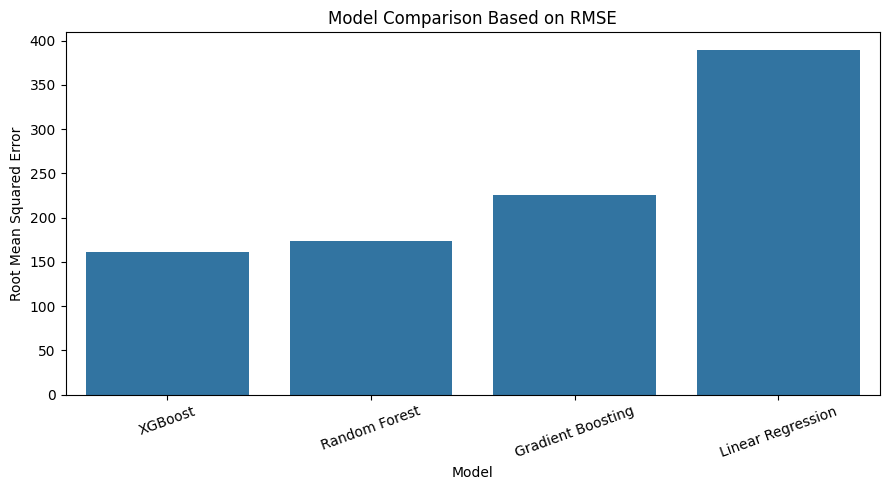

In [51]:
# ============================================================
# Plot Model Comparison Based on RMSE
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

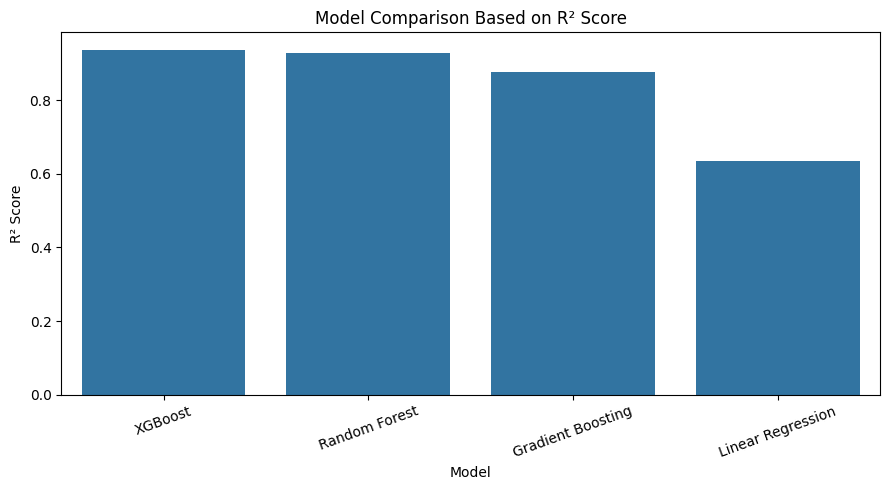

In [52]:
# ============================================================
# Plot Model Comparison Based on R² Score
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# Identify Best Performing Model
# ============================================================

# Storing all model predictions
predictions_dict = {
    "Linear Regression": np.maximum(linear_predictions, 0),
    "Random Forest": np.maximum(rf_predictions, 0),
    "Gradient Boosting": np.maximum(gb_predictions, 0),
    "XGBoost": np.maximum(xgb_predictions, 0)
}

# Storing all trained models
models_dict = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

# Selecting best model based on lowest RMSE
best_model_name = results_df.iloc[0]["Model"]

# best model predictions
best_predictions = predictions_dict[best_model_name]

print("Best performing model based on RMSE:", best_model_name)

Best performing model based on RMSE: XGBoost


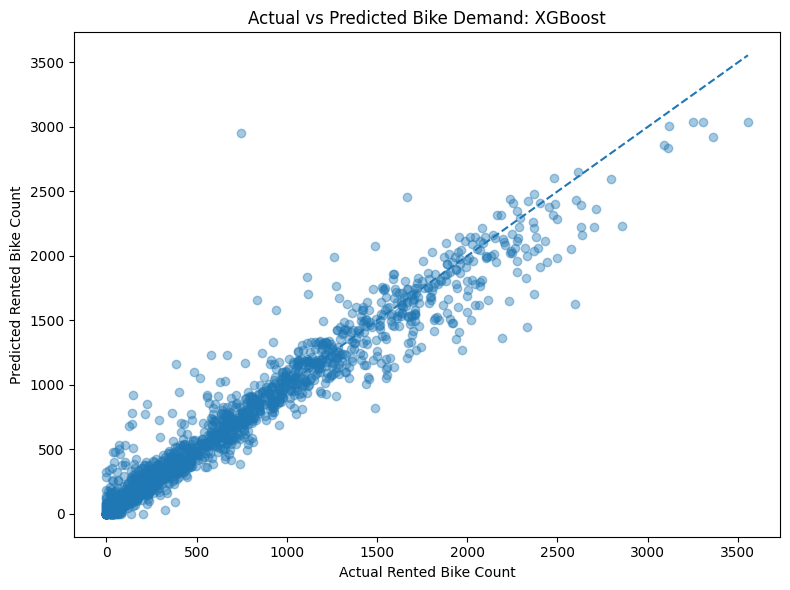

In [54]:
# ============================================================
# Actual vs Predicted Plot for Best Model
# ============================================================

plt.figure(figsize=(8, 6))

# Scatter plot of actual and predicted values
plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(f"Actual vs Predicted Bike Demand: {best_model_name}")
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.tight_layout()
plt.show()

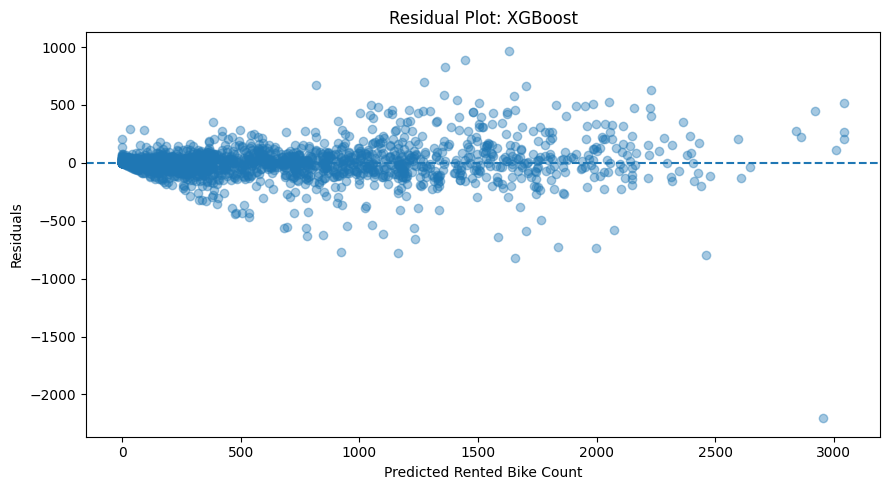

Residual Summary:
count    1752.000000
mean        1.511575
std       161.044511
min     -2206.165039
25%       -55.597643
50%         0.000000
75%        50.045673
max       968.309937
Name: Rented_Bike_Count, dtype: float64


In [55]:
# ============================================================
# Residual Plot for Best Model
# ============================================================

# Calculating residuals
# Residual = actual value - predicted value
residuals = y_test - best_predictions

plt.figure(figsize=(9, 5))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.4
)

# Horizontal line at zero error
plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(f"Residual Plot: {best_model_name}")
plt.xlabel("Predicted Rented Bike Count")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

print("Residual Summary:")
print(pd.Series(residuals).describe())

In [56]:
# ============================================================
# K-Fold Cross-Validation
# ============================================================

# required libraries
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Defining models for cross-validation
cv_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
}

#  5-fold cross-validation
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Defining scoring metrics
scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2"
}

# Empty list to store results
cv_results = []

# Running cross-validation for each model
for model_name, model in cv_models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=kfold,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV_MAE": -scores["test_MAE"].mean(),
        "CV_RMSE": np.sqrt(-scores["test_MSE"].mean()),
        "CV_R2": scores["test_R2"].mean()
    })

# Converting results into DataFrame
cv_results_df = pd.DataFrame(cv_results).round(3)

# Sorting by RMSE
cv_results_df = cv_results_df.sort_values(by="CV_RMSE")

print("K-Fold Cross-Validation Results:")
cv_results_df

K-Fold Cross-Validation Results:


,Model,CV_MAE,CV_RMSE,CV_R2
3,XGBoost,96.676,157.074,0.941
1,Random Forest,94.201,163.874,0.935
2,Gradient Boosting,141.889,216.229,0.888
0,Linear Regression,304.391,403.634,0.608


In [57]:
# ============================================================
#  Time-Series Cross-Validation
# ============================================================

# Importing TimeSeriesSplit
from sklearn.model_selection import TimeSeriesSplit

# Creating time-series split
tscv = TimeSeriesSplit(n_splits=5)

# Empty list to store time-series
time_cv_results = []

# Run time-series cross-validation for each model
for model_name, model in cv_models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1
    )

    time_cv_results.append({
        "Model": model_name,
        "Time_CV_MAE": -scores["test_MAE"].mean(),
        "Time_CV_RMSE": np.sqrt(-scores["test_MSE"].mean()),
        "Time_CV_R2": scores["test_R2"].mean()
    })

# Converting results into DataFrame
time_cv_results_df = pd.DataFrame(time_cv_results).round(3)

# Sorting by RMSE
time_cv_results_df = time_cv_results_df.sort_values(by="Time_CV_RMSE")

print("Time-Series Cross-Validation Results:")
time_cv_results_df

Time-Series Cross-Validation Results:


,Model,Time_CV_MAE,Time_CV_RMSE,Time_CV_R2
3,XGBoost,240.228,345.756,0.625
1,Random Forest,252.032,368.755,0.582
2,Gradient Boosting,268.634,373.170,0.580
0,Linear Regression,354.443,482.968,0.405


Best tree-based model: XGBoost

Top 15 Important Features:


,Feature,Importance
14,Seasons_Winter,0.268144
16,Functioning_Day_Yes,0.184251
1,TemperatureC,0.088241
0,Hour,0.086141
7,Rainfallmm,0.064883
18,Is_Peak_Hour,0.051121
2,Humidity,0.047830
17,Is_Weekend,0.045189
6,Solar_Radiation_MJ_m2,0.040122
10,Month,0.030941


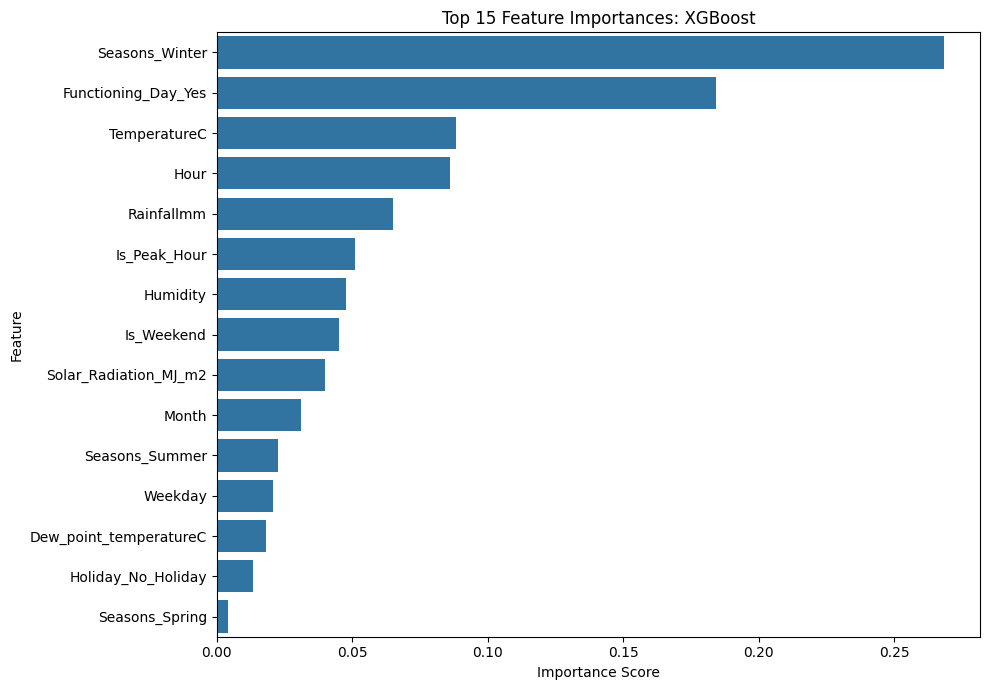

In [58]:
# ============================================================
# Feature Importance for Best Tree-Based Model
# ============================================================

# Selecting only tree-based models
tree_model_names = [
    "Random Forest",
    "Gradient Boosting",
    "XGBoost"
]

# Selecting best tree-based model based on RMSE
tree_results = results_df[
    results_df["Model"].isin(tree_model_names)
]

best_tree_model_name = tree_results.sort_values(by="RMSE").iloc[0]["Model"]

best_tree_model = models_dict[best_tree_model_name]

# Create feature importance table
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_tree_model.feature_importances_
})

# Sorting features by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Best tree-based model:", best_tree_model_name)
print("\nTop 15 Important Features:")
display(feature_importance_df.head(15))

# Plotting top 15 features
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(f"Top 15 Feature Importances: {best_tree_model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# Functioning Day Ablation Test
# ============================================================

# Identifying Functioning Day related columns
functioning_cols = [
    col for col in X.columns
    if "Functioning_Day" in col
]

print("Functioning Day columns found:", functioning_cols)

# Creating a new feature dataset without Functioning Day column
X_without_functioning = X.drop(columns=functioning_cols)

# Splitting the new dataset into training and testing sets
X_train_nf, X_test_nf, y_train_nf, y_test_nf = train_test_split(
    X_without_functioning,
    y,
    test_size=0.20,
    random_state=42
)

# Creating XGBoost model without Functioning Day
xgb_without_functioning = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Training the model without Functioning Day
xgb_without_functioning.fit(X_train_nf, y_train_nf)

# Predicting using the model without Functioning Day
pred_without_functioning = xgb_without_functioning.predict(X_test_nf)

# Comparing XGBoost with and without Functioning Day
ablation_results = pd.DataFrame([
    evaluate_regression_model(
        "XGBoost With Functioning Day",
        y_test,
        xgb_predictions
    ),
    evaluate_regression_model(
        "XGBoost Without Functioning Day",
        y_test_nf,
        pred_without_functioning
    )
])

# Round results
ablation_results = ablation_results.round(3)

print("Functioning Day Ablation Test Results:")
ablation_results

Functioning Day columns found: ['Functioning_Day_Yes']
Functioning Day Ablation Test Results:


,Model,MAE,RMSE,R2 Score
0,XGBoost With Functioning Day,94.535,161.006,0.938
1,XGBoost Without Functioning Day,115.354,198.883,0.905


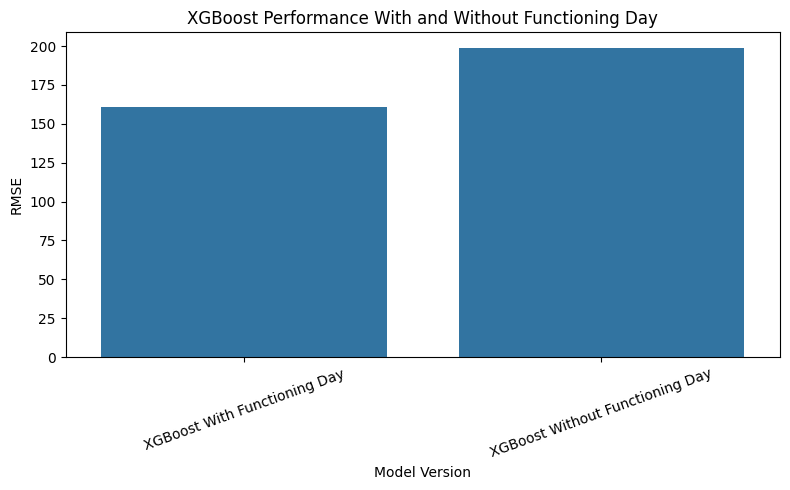

In [60]:
# ============================================================
#  Plotting Functioning Day Ablation Results
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=ablation_results,
    x="Model",
    y="RMSE"
)

plt.title("XGBoost Performance With and Without Functioning Day")
plt.xlabel("Model Version")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [61]:
# ============================================================
#  Save Final Results Tables
# ============================================================

# Saving model performance comparison
results_df.to_csv(
    "model_performance_results.csv",
    index=False
)

# Saving K-Fold cross-validation results
cv_results_df.to_csv(
    "kfold_cross_validation_results.csv",
    index=False
)

# Saving time-series cross-validation results
time_cv_results_df.to_csv(
    "time_series_cross_validation_results.csv",
    index=False
)

# Saving feature importance results
feature_importance_df.to_csv(
    "feature_importance_results.csv",
    index=False
)

# Saving Functioning Day ablation results
ablation_results.to_csv(
    "functioning_day_ablation_results.csv",
    index=False
)

print("All final result tables saved successfully.")

All final result tables saved successfully.


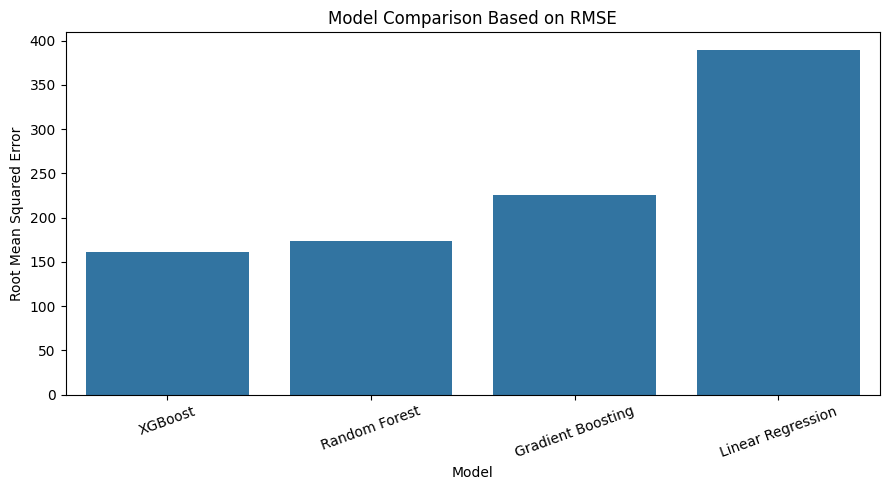

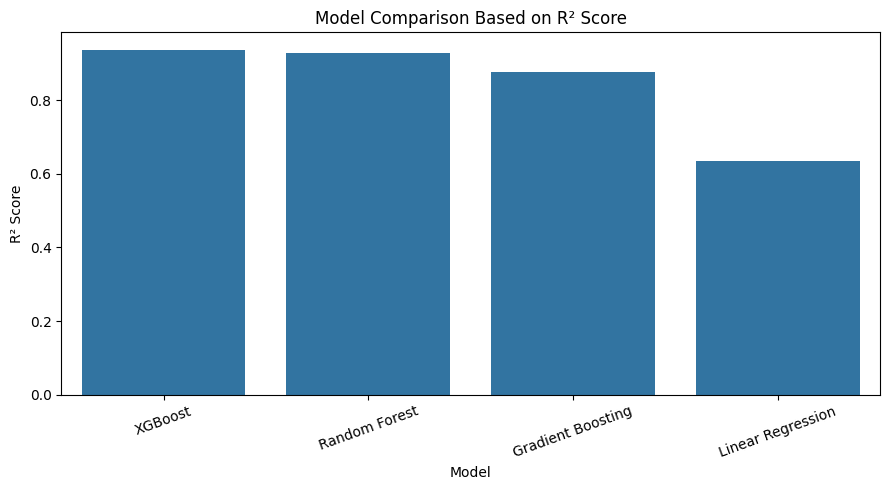

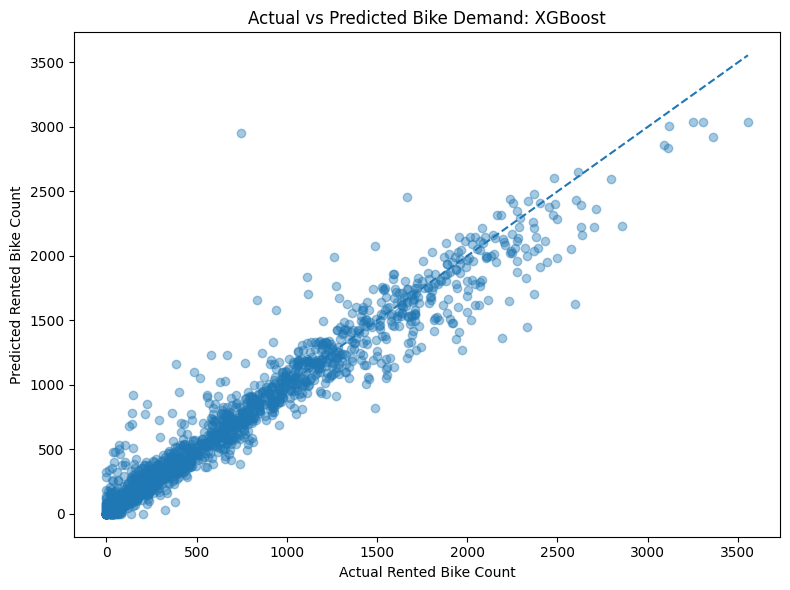

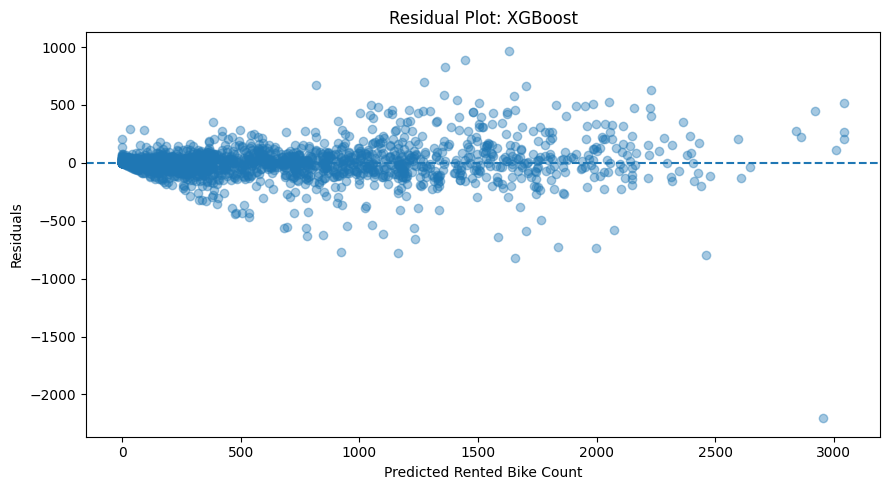

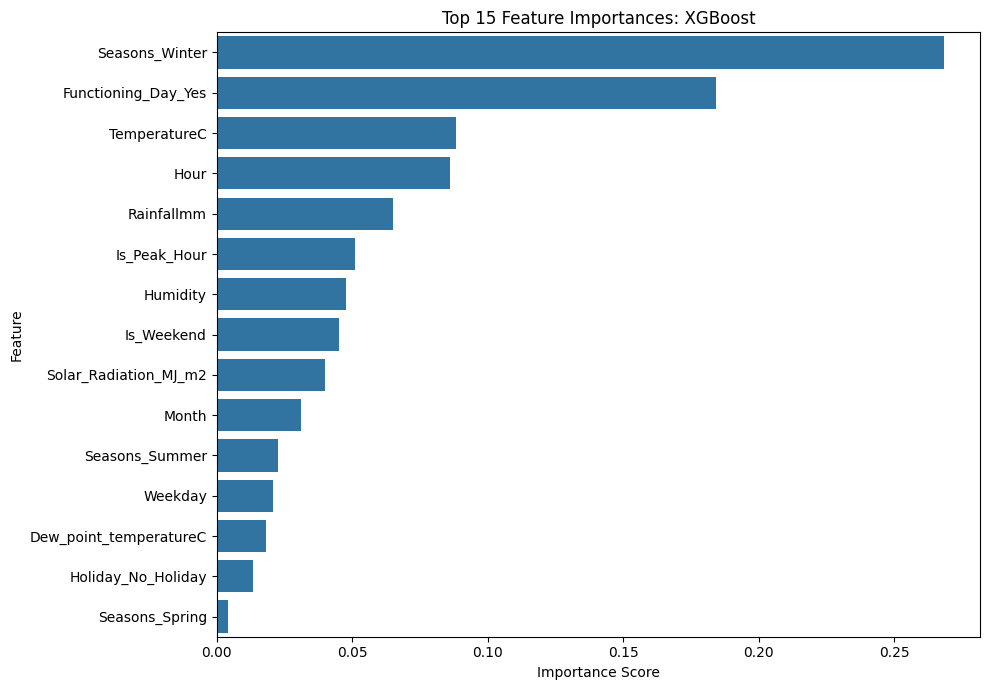

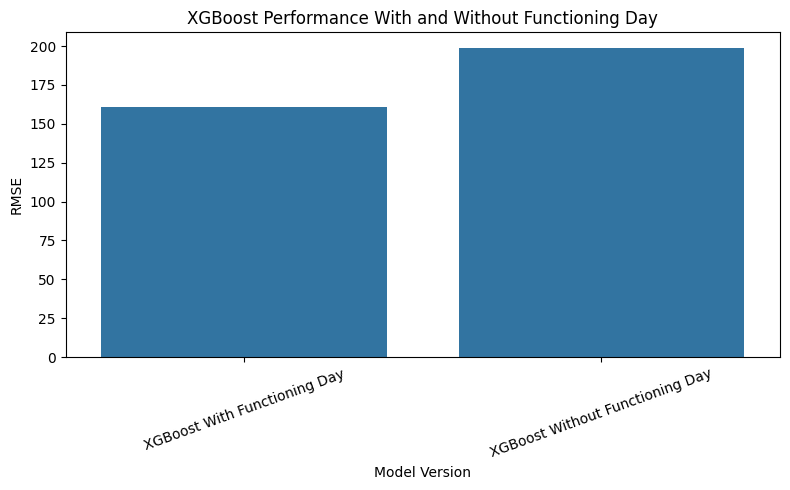

All important figures saved successfully.


In [62]:
# ============================================================
# Saving Important Figures as PNG Files
# ============================================================

# 1. Saving RMSE comparison plot
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("model_comparison_rmse.png", dpi=300)
plt.show()

# 2. Saving R2 comparison plot
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Model", y="R2 Score")
plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("model_comparison_r2.png", dpi=300)
plt.show()

# 3. Saving Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_predictions, alpha=0.4)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.title(f"Actual vs Predicted Bike Demand: {best_model_name}")
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.tight_layout()
plt.savefig("actual_vs_predicted_best_model.png", dpi=300)
plt.show()

# 4. Saving residual plot
plt.figure(figsize=(9, 5))
plt.scatter(best_predictions, residuals, alpha=0.4)
plt.axhline(y=0, linestyle="--")
plt.title(f"Residual Plot: {best_model_name}")
plt.xlabel("Predicted Rented Bike Count")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("residual_plot_best_model.png", dpi=300)
plt.show()

# 5. Saving feature importance plot
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)
plt.title(f"Top 15 Feature Importances: {best_tree_model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance_top15.png", dpi=300)
plt.show()

# 6. Saving Functioning Day ablation plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ablation_results,
    x="Model",
    y="RMSE"
)
plt.title("XGBoost Performance With and Without Functioning Day")
plt.xlabel("Model Version")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("functioning_day_ablation_rmse.png", dpi=300)
plt.show()

print("All important figures saved successfully.")

Parallel Work

In [63]:
# ============================================================
# Parallel Dataset Study
# ============================================================

print("Parallel Dataset Study: Washington D.C. Bike Sharing Dataset")
print("This section uses the UCI Bike Sharing Dataset / Capital Bikeshare hourly dataset.")
print("The purpose is to perform additional cross-validation and separate model evaluation for comparison.")

Parallel Dataset Study: Washington D.C. Bike Sharing Dataset
This section uses the UCI Bike Sharing Dataset / Capital Bikeshare hourly dataset.
The purpose is to perform additional cross-validation and separate model evaluation for comparison.


In [64]:
# ============================================================
#  Downloading Washington D.C. Bike Sharing Dataset
# ============================================================

# Downloading the UCI Bike Sharing Dataset zip file
!wget -O washington_bike_sharing_dataset.zip "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"

# Unzip the downloaded file
!unzip -o washington_bike_sharing_dataset.zip

print("Washington D.C. Bike Sharing dataset downloaded and extracted successfully.")

--2026-07-31 06:30:28--  https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘washington_bike_sharing_dataset.zip’

washington_bike_sha     [ <=>                ] 273.43K  1.42MB/s    in 0.2s    

2026-07-31 06:30:28 (1.42 MB/s) - ‘washington_bike_sharing_dataset.zip’ saved [279992]

Archive:  washington_bike_sharing_dataset.zip
  inflating: Readme.txt              
  inflating: day.csv                 
  inflating: hour.csv                
Washington D.C. Bike Sharing dataset downloaded and extracted successfully.


In [65]:
# ============================================================
#  Loading Washington D.C. Hourly Bike Dataset
# ============================================================

# Loading the hourly dataset
dc_df = pd.read_csv("hour.csv")

# Displaying dataset shape
print("Washington D.C. dataset shape:", dc_df.shape)

# Displaying first five rows
dc_df.head()

Washington D.C. dataset shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [66]:
# ============================================================
# Checking Washington D.C. Dataset Columns
# ============================================================

print("Washington D.C. dataset columns:")
print(dc_df.columns.tolist())

Washington D.C. dataset columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


In [67]:
# ============================================================
# Checking Dataset Information, Missing Values and Duplicates
# ============================================================

# Checking dataset information
print("Dataset Information:")
dc_df.info()

print("\nMissing Values:")
print(dc_df.isnull().sum())

print("\nDuplicate Rows:")
print(dc_df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Missing Values:
instant    

In [68]:
# ============================================================
# Understanding Washington D.C. Dataset Columns
# ============================================================

# Displaying basic statistical summary
dc_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [69]:
# ============================================================
# Removing Unnecessary and Leakage Columns
# ============================================================

# Creating a copy for preprocessing
dc_model_df = dc_df.copy()

# Removing columns that are not suitable

dc_model_df = dc_model_df.drop(
    columns=[
        "instant",
        "casual",
        "registered"
    ]
)

print("Washington D.C. dataset shape after removing leakage columns:")
print(dc_model_df.shape)

print("\nRemaining columns:")
print(dc_model_df.columns.tolist())

Washington D.C. dataset shape after removing leakage columns:
(17379, 14)

Remaining columns:
['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


In [70]:
# ============================================================
# Converting Date Column and Create Date Features
# ============================================================

# Converting dteday into datetime format
dc_model_df["dteday"] = pd.to_datetime(dc_model_df["dteday"])

# Creating additional date-based features
dc_model_df["day"] = dc_model_df["dteday"].dt.day
dc_model_df["month_from_date"] = dc_model_df["dteday"].dt.month
dc_model_df["year_from_date"] = dc_model_df["dteday"].dt.year

# Dropping original date column after extracting useful features
dc_model_df = dc_model_df.drop(columns=["dteday"])

print("Washington D.C. dataset shape after date feature creation:")
print(dc_model_df.shape)

dc_model_df.head()

Washington D.C. dataset shape after date feature creation:
(17379, 16)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,day,month_from_date,year_from_date
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,1,1,2011
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,1,1,2011
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,1,1,2011
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,1,1,2011
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1,1,2011


In [71]:
# ============================================================
#  Creating Weekend and Peak-Hour Features
# ============================================================

# Creating weekend feature

dc_model_df["is_weekend"] = dc_model_df["weekday"].isin([0, 6]).astype(int)

# Creating peak-hour feature
# Same peak-hour logic used in Seoul dataset
peak_hours = [7, 8, 9, 17, 18, 19]

dc_model_df["is_peak_hour"] = dc_model_df["hr"].isin(peak_hours).astype(int)

print("Weekend value counts:")
print(dc_model_df["is_weekend"].value_counts())

print("\nPeak-hour value counts:")
print(dc_model_df["is_peak_hour"].value_counts())

dc_model_df[
    [
        "hr",
        "weekday",
        "is_weekend",
        "is_peak_hour"
    ]
].head(10)

Weekend value counts:
is_weekend
0    12365
1     5014
Name: count, dtype: int64

Peak-hour value counts:
is_peak_hour
0    13012
1     4367
Name: count, dtype: int64


,hr,weekday,is_weekend,is_peak_hour
0,0,6,1,0
1,1,6,1,0
2,2,6,1,0
3,3,6,1,0
4,4,6,1,0
5,5,6,1,0
6,6,6,1,0
7,7,6,1,1
8,8,6,1,1
9,9,6,1,1


In [72]:
# ============================================================
# Renaming Washington D.C. Columns
# ============================================================

dc_model_df = dc_model_df.rename(
    columns={
        "season": "Season",
        "yr": "Year",
        "mnth": "Month",
        "hr": "Hour",
        "holiday": "Holiday",
        "weekday": "Weekday",
        "workingday": "Working_Day",
        "weathersit": "Weather_Situation",
        "temp": "Temperature_Normalized",
        "atemp": "Feeling_Temperature_Normalized",
        "hum": "Humidity_Normalized",
        "windspeed": "Wind_Speed_Normalized",
        "cnt": "Rented_Bike_Count",
        "day": "Day",
        "month_from_date": "Month_From_Date",
        "year_from_date": "Year_From_Date",
        "is_weekend": "Is_Weekend",
        "is_peak_hour": "Is_Peak_Hour"
    }
)

print("Final Washington D.C. modelling columns:")
print(dc_model_df.columns.tolist())

print("\nFinal Washington D.C. modelling dataset shape:")
print(dc_model_df.shape)

dc_model_df.head()

Final Washington D.C. modelling columns:
['Season', 'Year', 'Month', 'Hour', 'Holiday', 'Weekday', 'Working_Day', 'Weather_Situation', 'Temperature_Normalized', 'Feeling_Temperature_Normalized', 'Humidity_Normalized', 'Wind_Speed_Normalized', 'Rented_Bike_Count', 'Day', 'Month_From_Date', 'Year_From_Date', 'Is_Weekend', 'Is_Peak_Hour']

Final Washington D.C. modelling dataset shape:
(17379, 18)


,Season,Year,Month,Hour,Holiday,Weekday,Working_Day,Weather_Situation,Temperature_Normalized,Feeling_Temperature_Normalized,Humidity_Normalized,Wind_Speed_Normalized,Rented_Bike_Count,Day,Month_From_Date,Year_From_Date,Is_Weekend,Is_Peak_Hour
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,1,1,2011,1,0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,1,1,2011,1,0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,1,1,2011,1,0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,1,1,2011,1,0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1,1,2011,1,0


In [73]:
# ============================================================
# Preparing Washington D.C. Dataset for Modelling
# ============================================================

# Creating a final copy for modelling
dc_final_df = dc_model_df.copy()

# One-hot encode categorical code columns

dc_final_df = pd.get_dummies(
    dc_final_df,
    columns=["Season", "Weather_Situation"],
    drop_first=True
)

# Converting any boolean columns into integers
bool_columns = dc_final_df.select_dtypes(include=["bool"]).columns
dc_final_df[bool_columns] = dc_final_df[bool_columns].astype(int)

print("Final Washington D.C. dataset shape after encoding:")
print(dc_final_df.shape)

print("\nFinal Washington D.C. columns:")
print(dc_final_df.columns.tolist())

dc_final_df.head()

Final Washington D.C. dataset shape after encoding:
(17379, 22)

Final Washington D.C. columns:
['Year', 'Month', 'Hour', 'Holiday', 'Weekday', 'Working_Day', 'Temperature_Normalized', 'Feeling_Temperature_Normalized', 'Humidity_Normalized', 'Wind_Speed_Normalized', 'Rented_Bike_Count', 'Day', 'Month_From_Date', 'Year_From_Date', 'Is_Weekend', 'Is_Peak_Hour', 'Season_2', 'Season_3', 'Season_4', 'Weather_Situation_2', 'Weather_Situation_3', 'Weather_Situation_4']


,Year,Month,Hour,Holiday,Weekday,Working_Day,Temperature_Normalized,Feeling_Temperature_Normalized,Humidity_Normalized,Wind_Speed_Normalized,...,Month_From_Date,Year_From_Date,Is_Weekend,Is_Peak_Hour,Season_2,Season_3,Season_4,Weather_Situation_2,Weather_Situation_3,Weather_Situation_4
0,0,1,0,0,6,0,0.24,0.2879,0.81,0.0,...,1,2011,1,0,0,0,0,0,0,0
1,0,1,1,0,6,0,0.22,0.2727,0.80,0.0,...,1,2011,1,0,0,0,0,0,0,0
2,0,1,2,0,6,0,0.22,0.2727,0.80,0.0,...,1,2011,1,0,0,0,0,0,0,0
3,0,1,3,0,6,0,0.24,0.2879,0.75,0.0,...,1,2011,1,0,0,0,0,0,0,0
4,0,1,4,0,6,0,0.24,0.2879,0.75,0.0,...,1,2011,1,0,0,0,0,0,0,0


In [74]:
# ============================================================
# Separate Washington D.C. Features and Target
# ============================================================

# Defining target variable
dc_target = "Rented_Bike_Count"

# X contains input features
X_dc = dc_final_df.drop(columns=[dc_target])

# y contains target variable
y_dc = dc_final_df[dc_target]

print("Washington D.C. feature dataset shape:", X_dc.shape)
print("Washington D.C. target dataset shape:", y_dc.shape)

Washington D.C. feature dataset shape: (17379, 21)
Washington D.C. target dataset shape: (17379,)


In [75]:
# ============================================================
# Train-Test Split and Scaling for Washington D.C.
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Splitting Washington D.C. dataset into 80% training and 20% testing
X_dc_train, X_dc_test, y_dc_train, y_dc_test = train_test_split(
    X_dc,
    y_dc,
    test_size=0.20,
    random_state=42
)

# Scaling for Linear Regression
dc_scaler = StandardScaler()

X_dc_train_scaled = dc_scaler.fit_transform(X_dc_train)
X_dc_test_scaled = dc_scaler.transform(X_dc_test)

print("X_dc_train shape:", X_dc_train.shape)
print("X_dc_test shape:", X_dc_test.shape)
print("y_dc_train shape:", y_dc_train.shape)
print("y_dc_test shape:", y_dc_test.shape)

print("\nScaling completed for Washington D.C. Linear Regression.")

X_dc_train shape: (13903, 21)
X_dc_test shape: (3476, 21)
y_dc_train shape: (13903,)
y_dc_test shape: (3476,)

Scaling completed for Washington D.C. Linear Regression.


In [76]:
# ============================================================
# Train and Evaluate Washington D.C. Models
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluation function for Washington D.C.
def evaluate_dc_model(model_name, y_true, y_pred):
    # Bike rental count cannot be negative
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

# 1. Linear Regression
dc_linear_model = LinearRegression()
dc_linear_model.fit(X_dc_train_scaled, y_dc_train)
dc_linear_predictions = dc_linear_model.predict(X_dc_test_scaled)

dc_linear_results = evaluate_dc_model(
    "Linear Regression",
    y_dc_test,
    dc_linear_predictions
)

# 2. Random Forest
dc_rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

dc_rf_model.fit(X_dc_train, y_dc_train)
dc_rf_predictions = dc_rf_model.predict(X_dc_test)

dc_rf_results = evaluate_dc_model(
    "Random Forest",
    y_dc_test,
    dc_rf_predictions
)

# 3. Gradient Boosting
dc_gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

dc_gb_model.fit(X_dc_train, y_dc_train)
dc_gb_predictions = dc_gb_model.predict(X_dc_test)

dc_gb_results = evaluate_dc_model(
    "Gradient Boosting",
    y_dc_test,
    dc_gb_predictions
)

# 4. XGBoost
dc_xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

dc_xgb_model.fit(X_dc_train, y_dc_train)
dc_xgb_predictions = dc_xgb_model.predict(X_dc_test)

dc_xgb_results = evaluate_dc_model(
    "XGBoost",
    y_dc_test,
    dc_xgb_predictions
)

print("Washington D.C. model training and evaluation completed.")
print(dc_linear_results)
print(dc_rf_results)
print(dc_gb_results)
print(dc_xgb_results)

Washington D.C. model training and evaluation completed.
{'Model': 'Linear Regression', 'MAE': 83.83820515861657, 'RMSE': np.float64(114.40025178828155), 'R2 Score': 0.5866967439594086}
{'Model': 'Random Forest', 'MAE': 24.117938722669734, 'RMSE': np.float64(41.01909107601995), 'R2 Score': 0.9468642357168542}
{'Model': 'Gradient Boosting', 'MAE': 38.17386960003941, 'RMSE': np.float64(56.23680659422537), 'R2 Score': 0.9001251434155475}
{'Model': 'XGBoost', 'MAE': 25.71742820739746, 'RMSE': np.float64(40.54857896226913), 'R2 Score': 0.9480762481689453}


Washington D.C. Model Performance Comparison:


,Model,MAE,RMSE,R2 Score
3,XGBoost,25.717,40.549,0.948
1,Random Forest,24.118,41.019,0.947
2,Gradient Boosting,38.174,56.237,0.900
0,Linear Regression,83.838,114.400,0.587


Best Washington D.C. model based on RMSE: XGBoost


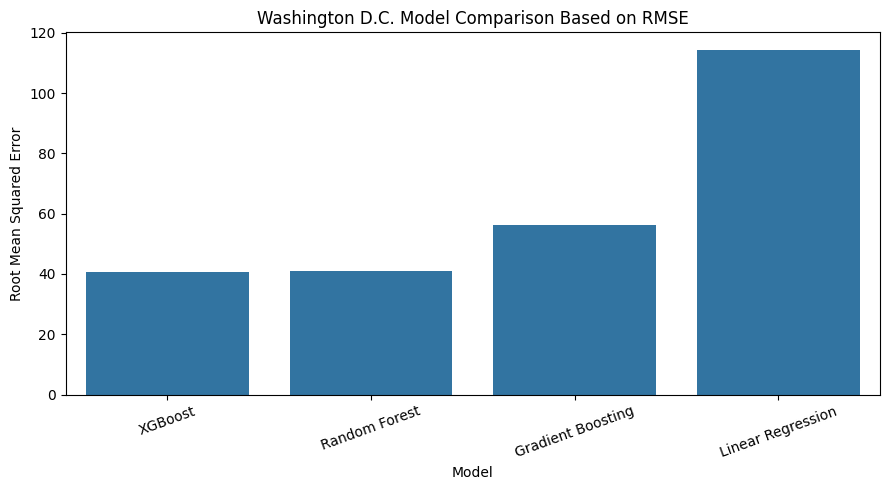

In [77]:
# ============================================================
#  Washington D.C. Model Comparison Table
# ============================================================

# Combining all Washington D.C. model results
dc_results_df = pd.DataFrame([
    dc_linear_results,
    dc_rf_results,
    dc_gb_results,
    dc_xgb_results
])

# Round values
dc_results_df = dc_results_df.round(3)

# Sorting by RMSE
dc_results_df = dc_results_df.sort_values(by="RMSE")

print("Washington D.C. Model Performance Comparison:")
display(dc_results_df)

# Identifying best model
dc_best_model_name = dc_results_df.iloc[0]["Model"]

print("Best Washington D.C. model based on RMSE:", dc_best_model_name)

# Plot RMSE comparison
plt.figure(figsize=(9, 5))
sns.barplot(
    data=dc_results_df,
    x="Model",
    y="RMSE"
)

plt.title("Washington D.C. Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [78]:
# ============================================================
# K-Fold Cross-Validation on Washington D.C. Dataset
# ============================================================

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Defining models for Washington D.C. cross-validation
dc_cv_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
}

# Defining 5-fold cross-validation
dc_kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Defining scoring metrics
dc_scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2"
}

# Storing cross-validation results
dc_cv_results = []

for model_name, model in dc_cv_models.items():

    scores = cross_validate(
        model,
        X_dc,
        y_dc,
        cv=dc_kfold,
        scoring=dc_scoring,
        n_jobs=-1
    )

    dc_cv_results.append({
        "Model": model_name,
        "CV_MAE": -scores["test_MAE"].mean(),
        "CV_RMSE": np.sqrt(-scores["test_MSE"].mean()),
        "CV_R2": scores["test_R2"].mean()
    })

# Converting results into DataFrame
dc_cv_results_df = pd.DataFrame(dc_cv_results).round(3)

# Sorting by RMSE
dc_cv_results_df = dc_cv_results_df.sort_values(by="CV_RMSE")

print("Washington D.C. K-Fold Cross-Validation Results:")
display(dc_cv_results_df)

Washington D.C. K-Fold Cross-Validation Results:


,Model,CV_MAE,CV_RMSE,CV_R2
1,Random Forest,24.583,41.179,0.948
3,XGBoost,26.621,41.699,0.947
2,Gradient Boosting,41.136,59.953,0.891
0,Linear Regression,89.000,118.792,0.571


In [79]:
# ============================================================
# Time-Series Cross-Validation on Washington D.C. Dataset
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

# Defining time-series split
dc_tscv = TimeSeriesSplit(n_splits=5)

# Storing time-series cross-validation results
dc_time_cv_results = []

for model_name, model in dc_cv_models.items():

    scores = cross_validate(
        model,
        X_dc,
        y_dc,
        cv=dc_tscv,
        scoring=dc_scoring,
        n_jobs=-1
    )

    dc_time_cv_results.append({
        "Model": model_name,
        "Time_CV_MAE": -scores["test_MAE"].mean(),
        "Time_CV_RMSE": np.sqrt(-scores["test_MSE"].mean()),
        "Time_CV_R2": scores["test_R2"].mean()
    })

# Converting results into DataFrame
dc_time_cv_results_df = pd.DataFrame(dc_time_cv_results).round(3)

# Sorting by RMSE
dc_time_cv_results_df = dc_time_cv_results_df.sort_values(by="Time_CV_RMSE")

print("Washington D.C. Time-Series Cross-Validation Results:")
display(dc_time_cv_results_df)

Washington D.C. Time-Series Cross-Validation Results:


,Model,Time_CV_MAE,Time_CV_RMSE,Time_CV_R2
3,XGBoost,51.766,78.699,0.800
1,Random Forest,55.133,85.752,0.761
2,Gradient Boosting,65.150,94.241,0.720
0,Linear Regression,100.463,135.172,0.441


Best Washington D.C. tree-based model: XGBoost

Top 15 Important Features for Washington D.C.:


,Feature,Importance
14,Is_Peak_Hour,0.166914
2,Hour,0.128247
0,Year,0.116081
5,Working_Day,0.106677
13,Is_Weekend,0.091081
12,Year_From_Date,0.088156
7,Feeling_Temperature_Normalized,0.059627
17,Season_4,0.057563
6,Temperature_Normalized,0.055836
19,Weather_Situation_3,0.043799


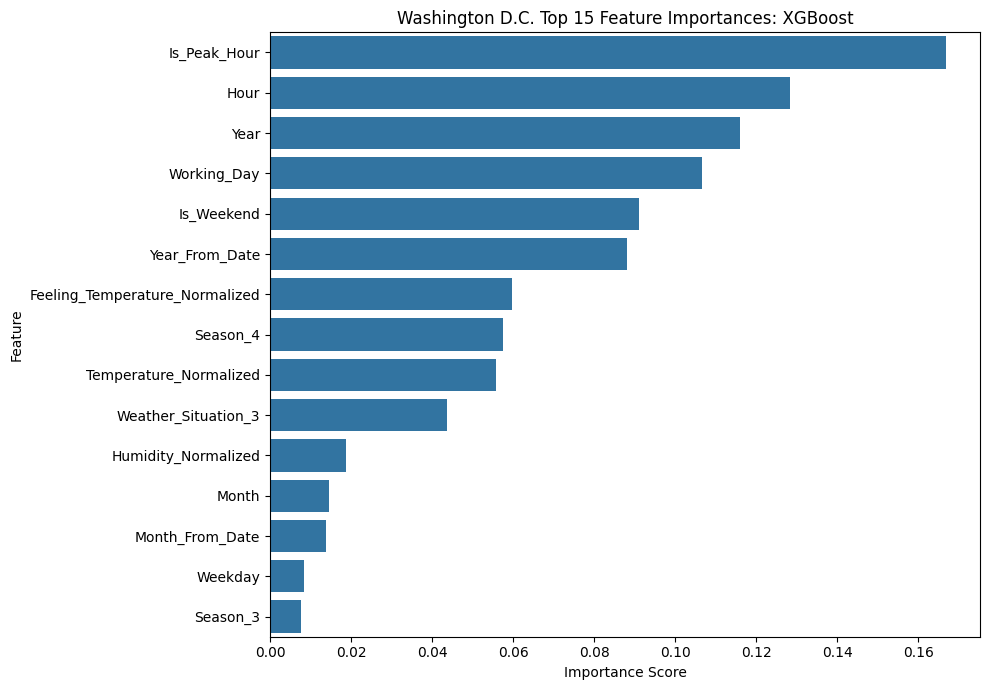

In [80]:
# ============================================================
# Washington D.C. Feature Importance
# ============================================================

# Storing trained Washington D.C. models
dc_models_dict = {
    "Linear Regression": dc_linear_model,
    "Random Forest": dc_rf_model,
    "Gradient Boosting": dc_gb_model,
    "XGBoost": dc_xgb_model
}

# Storing Washington D.C. predictions
dc_predictions_dict = {
    "Linear Regression": np.maximum(dc_linear_predictions, 0),
    "Random Forest": np.maximum(dc_rf_predictions, 0),
    "Gradient Boosting": np.maximum(dc_gb_predictions, 0),
    "XGBoost": np.maximum(dc_xgb_predictions, 0)
}

# Selecting only tree-based models
dc_tree_model_names = [
    "Random Forest",
    "Gradient Boosting",
    "XGBoost"
]

# Selecting best tree-based model based on normal test RMSE
dc_tree_results = dc_results_df[
    dc_results_df["Model"].isin(dc_tree_model_names)
]

dc_best_tree_model_name = dc_tree_results.sort_values(by="RMSE").iloc[0]["Model"]
dc_best_tree_model = dc_models_dict[dc_best_tree_model_name]

# Creating feature importance table
dc_feature_importance_df = pd.DataFrame({
    "Feature": X_dc.columns,
    "Importance": dc_best_tree_model.feature_importances_
})

# Sorting features by importance
dc_feature_importance_df = dc_feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Best Washington D.C. tree-based model:", dc_best_tree_model_name)
print("\nTop 15 Important Features for Washington D.C.:")
display(dc_feature_importance_df.head(15))

# Plotting top 15 feature importances
dc_top_features = dc_feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=dc_top_features,
    x="Importance",
    y="Feature"
)

plt.title(f"Washington D.C. Top 15 Feature Importances: {dc_best_tree_model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

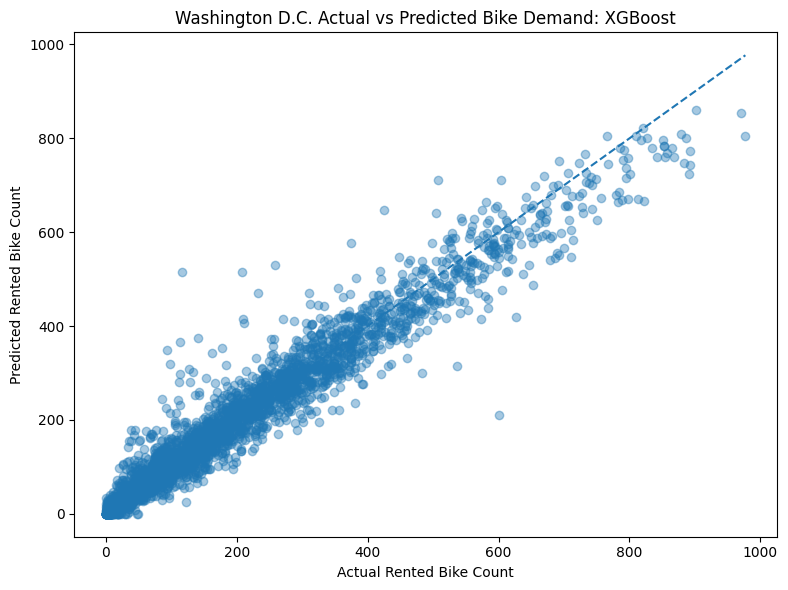

Best Washington D.C. model based on test RMSE: XGBoost


In [81]:
# ============================================================
# Washington D.C. Actual vs Predicted Plot
# ============================================================

# Selecting best Washington D.C. model based on test RMSE
dc_best_model_name = dc_results_df.iloc[0]["Model"]

# Getting predictions from the best model
dc_best_predictions = dc_predictions_dict[dc_best_model_name]

plt.figure(figsize=(8, 6))

plt.scatter(
    y_dc_test,
    dc_best_predictions,
    alpha=0.4
)

# Perfecting prediction reference line
plt.plot(
    [y_dc_test.min(), y_dc_test.max()],
    [y_dc_test.min(), y_dc_test.max()],
    linestyle="--"
)

plt.title(f"Washington D.C. Actual vs Predicted Bike Demand: {dc_best_model_name}")
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.tight_layout()
plt.show()

print("Best Washington D.C. model based on test RMSE:", dc_best_model_name)

Best Model Comparison: Seoul vs Washington D.C.


,Dataset,Best Model,MAE,RMSE,R2 Score
0,Seoul Bike Sharing Demand,XGBoost,94.535,161.006,0.938
1,Washington D.C. Bike Sharing,XGBoost,25.717,40.549,0.948


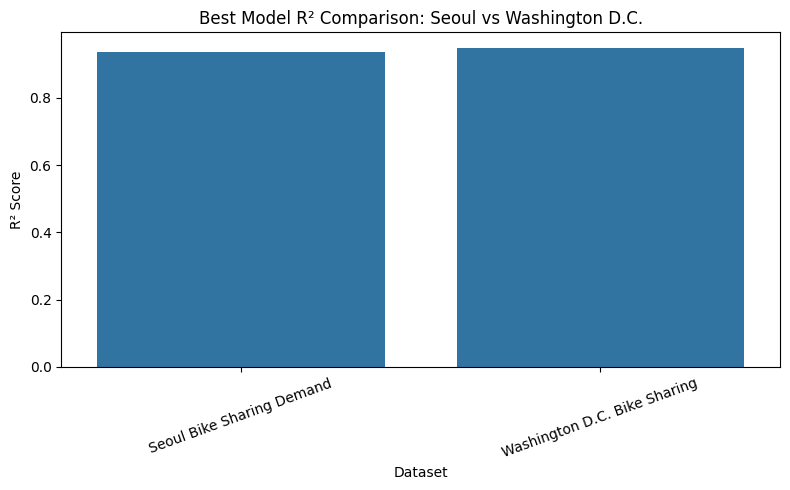

In [82]:
# ============================================================
# Comparing Seoul and Washington D.C. Best Results
# ============================================================

# Selecting best Seoul model result
seoul_best_result = results_df.iloc[0]

# Selecting best Washington D.C. model result
dc_best_result = dc_results_df.iloc[0]

# Creating comparison table
dataset_comparison_df = pd.DataFrame([
    {
        "Dataset": "Seoul Bike Sharing Demand",
        "Best Model": seoul_best_result["Model"],
        "MAE": seoul_best_result["MAE"],
        "RMSE": seoul_best_result["RMSE"],
        "R2 Score": seoul_best_result["R2 Score"]
    },
    {
        "Dataset": "Washington D.C. Bike Sharing",
        "Best Model": dc_best_result["Model"],
        "MAE": dc_best_result["MAE"],
        "RMSE": dc_best_result["RMSE"],
        "R2 Score": dc_best_result["R2 Score"]
    }
])

dataset_comparison_df = dataset_comparison_df.round(3)

print("Best Model Comparison: Seoul vs Washington D.C.")
display(dataset_comparison_df)

# Plot R2 comparison
plt.figure(figsize=(8, 5))

sns.barplot(
    data=dataset_comparison_df,
    x="Dataset",
    y="R2 Score"
)

plt.title("Best Model R² Comparison: Seoul vs Washington D.C.")
plt.xlabel("Dataset")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [83]:
# ============================================================
# Saving Washington D.C. Results
# ============================================================

# Saving Washington D.C. cleaned/preprocessed dataset
dc_final_df.to_csv(
    "washington_dc_preprocessed_bike_data.csv",
    index=False
)

# performance table
dc_results_df.to_csv(
    "washington_dc_model_performance_results.csv",
    index=False
)

#  K-Fold CV results
dc_cv_results_df.to_csv(
    "washington_dc_kfold_cross_validation_results.csv",
    index=False
)

#  Time-Series CV results
dc_time_cv_results_df.to_csv(
    "washington_dc_time_series_cross_validation_results.csv",
    index=False
)

#  Washington D.C. feature importance results
dc_feature_importance_df.to_csv(
    "washington_dc_feature_importance_results.csv",
    index=False
)

#  Seoul vs Washington comparison table
dataset_comparison_df.to_csv(
    "seoul_vs_washington_best_model_comparison.csv",
    index=False
)

print("Washington D.C. result files saved successfully.")

Washington D.C. result files saved successfully.


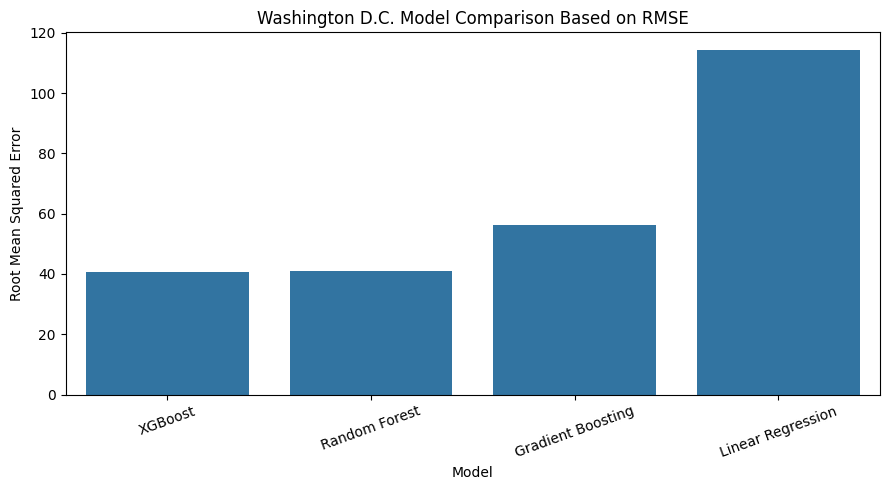

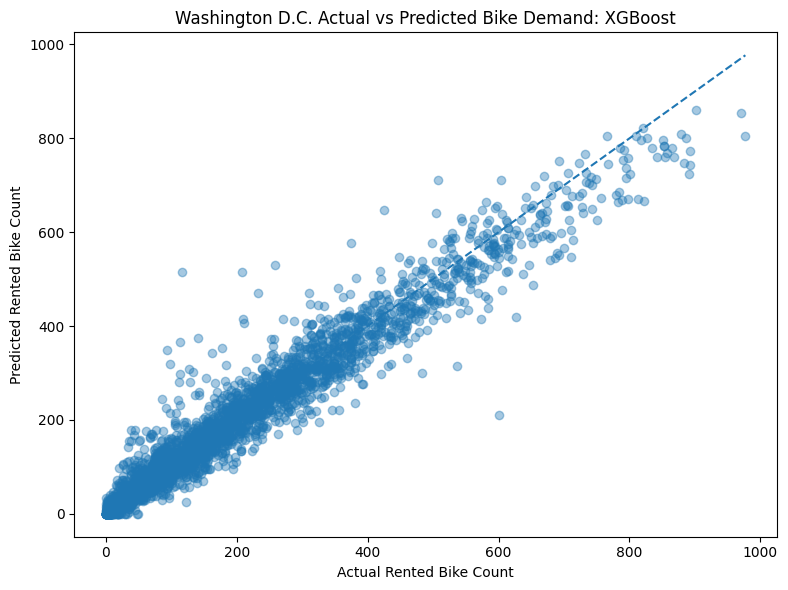

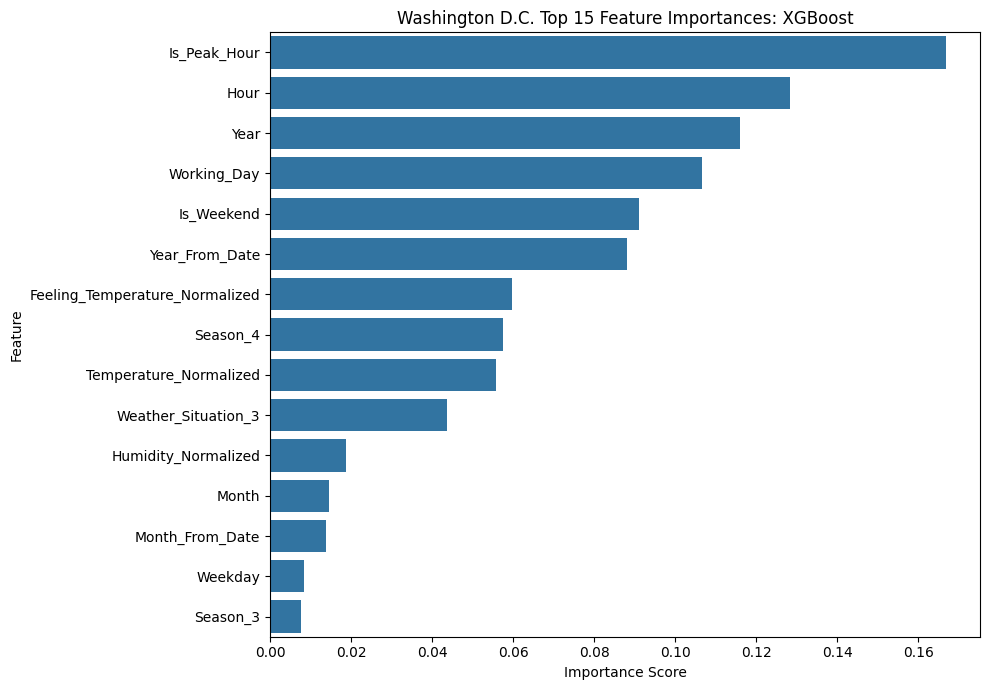

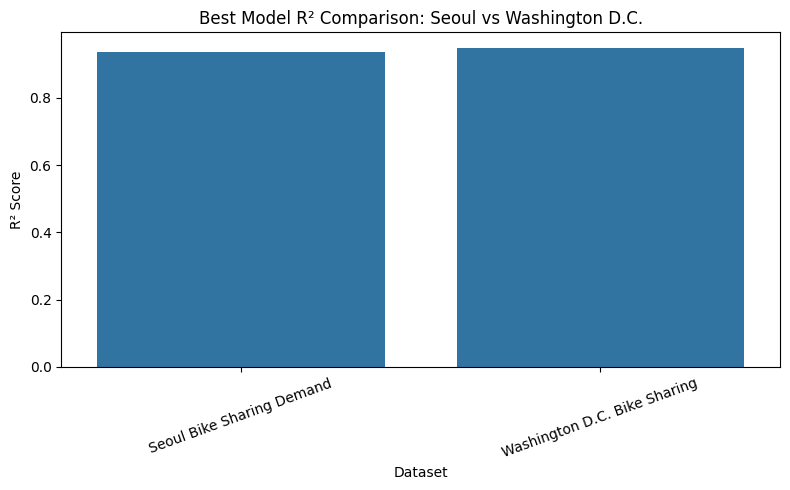

Washington D.C. figures saved successfully.


In [84]:
# ============================================================
#  Save Washington D.C. Figures
# ============================================================

# Washington D.C. RMSE comparison plot
plt.figure(figsize=(9, 5))

sns.barplot(
    data=dc_results_df,
    x="Model",
    y="RMSE"
)

plt.title("Washington D.C. Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("washington_dc_model_comparison_rmse.png", dpi=300)
plt.show()

#  Washington D.C. Actual vs Predicted plot
plt.figure(figsize=(8, 6))

plt.scatter(
    y_dc_test,
    dc_best_predictions,
    alpha=0.4
)

plt.plot(
    [y_dc_test.min(), y_dc_test.max()],
    [y_dc_test.min(), y_dc_test.max()],
    linestyle="--"
)

plt.title(f"Washington D.C. Actual vs Predicted Bike Demand: {dc_best_model_name}")
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.tight_layout()
plt.savefig("washington_dc_actual_vs_predicted.png", dpi=300)
plt.show()

#  Washington D.C. feature importance plot
dc_top_features = dc_feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=dc_top_features,
    x="Importance",
    y="Feature"
)

plt.title(f"Washington D.C. Top 15 Feature Importances: {dc_best_tree_model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("washington_dc_feature_importance_top15.png", dpi=300)
plt.show()

# Seoul vs Washington R2 comparison plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=dataset_comparison_df,
    x="Dataset",
    y="R2 Score"
)

plt.title("Best Model R² Comparison: Seoul vs Washington D.C.")
plt.xlabel("Dataset")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("seoul_vs_washington_r2_comparison.png", dpi=300)
plt.show()

print("Washington D.C. figures saved successfully.")

In [85]:
# ============================================================
# Creating Combined Test Performance Table
# ============================================================

# Adding dataset name to Seoul results
seoul_test_results = results_df.copy()
seoul_test_results["Dataset"] = "Seoul"

# Adding dataset name to Washington D.C. results
dc_test_results = dc_results_df.copy()
dc_test_results["Dataset"] = "Washington D.C."

# Combining both datasets' model performance results
combined_test_results = pd.concat(
    [seoul_test_results, dc_test_results],
    ignore_index=True
)

# Reordering columns
combined_test_results = combined_test_results[
    ["Dataset", "Model", "MAE", "RMSE", "R2 Score"]
]

# Sorting for readability
combined_test_results = combined_test_results.sort_values(
    by=["Dataset", "RMSE"]
)

print("Combined Test Performance Results: Seoul vs Washington D.C.")
display(combined_test_results)

Combined Test Performance Results: Seoul vs Washington D.C.


,Dataset,Model,MAE,RMSE,R2 Score
0,Seoul,XGBoost,94.535,161.006,0.938
1,Seoul,Random Forest,98.405,173.620,0.928
2,Seoul,Gradient Boosting,142.334,225.488,0.878
3,Seoul,Linear Regression,286.701,389.809,0.635
4,Washington D.C.,XGBoost,25.717,40.549,0.948
5,Washington D.C.,Random Forest,24.118,41.019,0.947
6,Washington D.C.,Gradient Boosting,38.174,56.237,0.900
7,Washington D.C.,Linear Regression,83.838,114.400,0.587


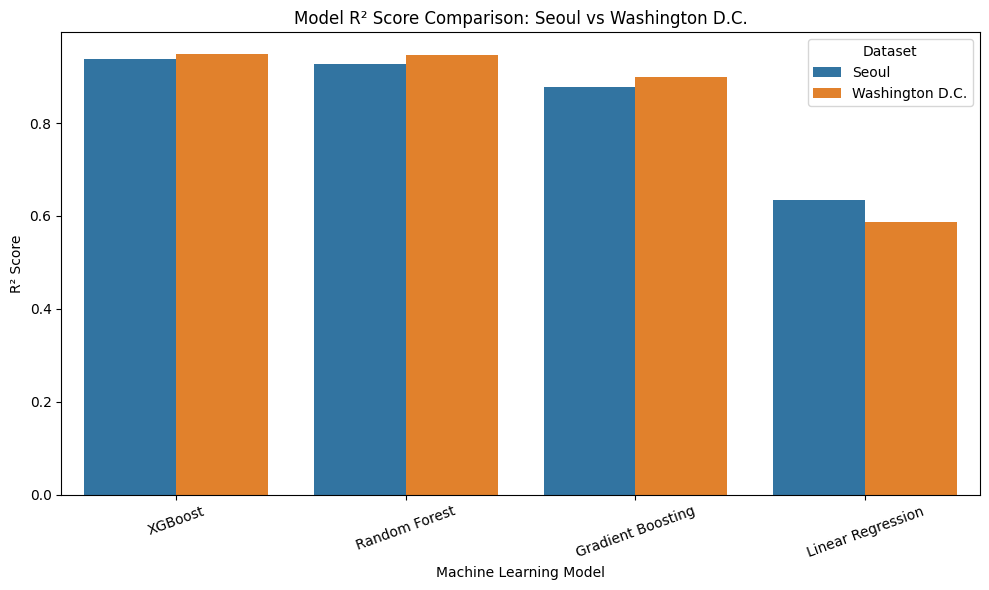

In [86]:
# ============================================================
# Plot R² Comparison Across Both Datasets
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=combined_test_results,
    x="Model",
    y="R2 Score",
    hue="Dataset"
)

plt.title("Model R² Score Comparison: Seoul vs Washington D.C.")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

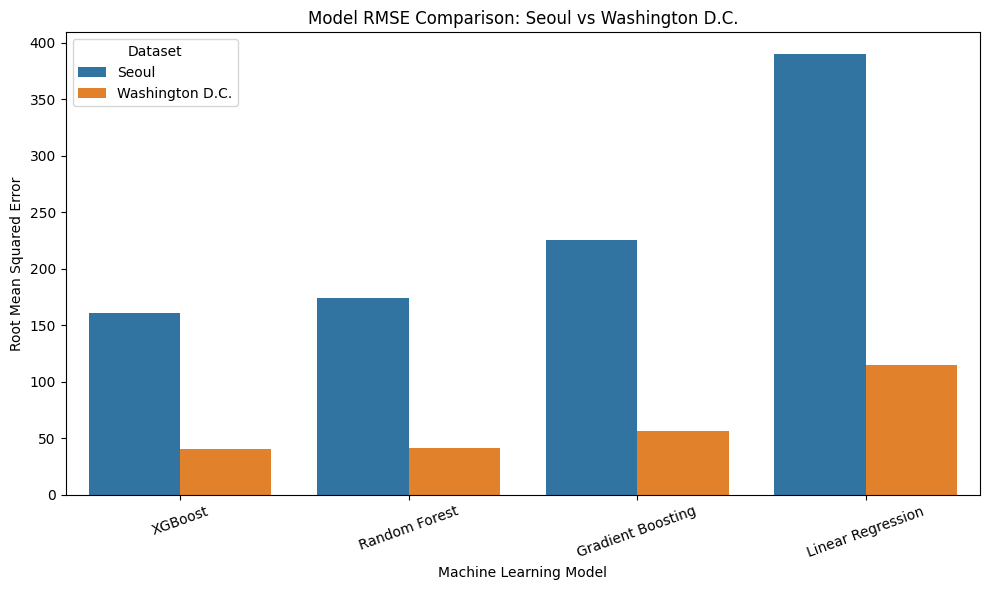

In [87]:
# ============================================================
# Plot RMSE Comparison Across Both Datasets
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=combined_test_results,
    x="Model",
    y="RMSE",
    hue="Dataset"
)

plt.title("Model RMSE Comparison: Seoul vs Washington D.C.")
plt.xlabel("Machine Learning Model")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=20)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

In [88]:
# ============================================================
# Creating Cross-Validation Comparison Table
# ============================================================

# Preparing Seoul K-Fold results
seoul_cv_summary = cv_results_df.copy()
seoul_cv_summary["Dataset"] = "Seoul"
seoul_cv_summary = seoul_cv_summary.rename(
    columns={
        "CV_MAE": "KFold_MAE",
        "CV_RMSE": "KFold_RMSE",
        "CV_R2": "KFold_R2"
    }
)

# Preparing Washington D.C. K-Fold results
dc_cv_summary = dc_cv_results_df.copy()
dc_cv_summary["Dataset"] = "Washington D.C."
dc_cv_summary = dc_cv_summary.rename(
    columns={
        "CV_MAE": "KFold_MAE",
        "CV_RMSE": "KFold_RMSE",
        "CV_R2": "KFold_R2"
    }
)

# Combining K-Fold results
combined_cv_results = pd.concat(
    [seoul_cv_summary, dc_cv_summary],
    ignore_index=True
)

combined_cv_results = combined_cv_results[
    ["Dataset", "Model", "KFold_MAE", "KFold_RMSE", "KFold_R2"]
]

combined_cv_results = combined_cv_results.sort_values(
    by=["Dataset", "KFold_RMSE"]
)

print("Combined K-Fold Cross-Validation Results:")
display(combined_cv_results)

Combined K-Fold Cross-Validation Results:


,Dataset,Model,KFold_MAE,KFold_RMSE,KFold_R2
0,Seoul,XGBoost,96.676,157.074,0.941
1,Seoul,Random Forest,94.201,163.874,0.935
2,Seoul,Gradient Boosting,141.889,216.229,0.888
3,Seoul,Linear Regression,304.391,403.634,0.608
4,Washington D.C.,Random Forest,24.583,41.179,0.948
5,Washington D.C.,XGBoost,26.621,41.699,0.947
6,Washington D.C.,Gradient Boosting,41.136,59.953,0.891
7,Washington D.C.,Linear Regression,89.000,118.792,0.571


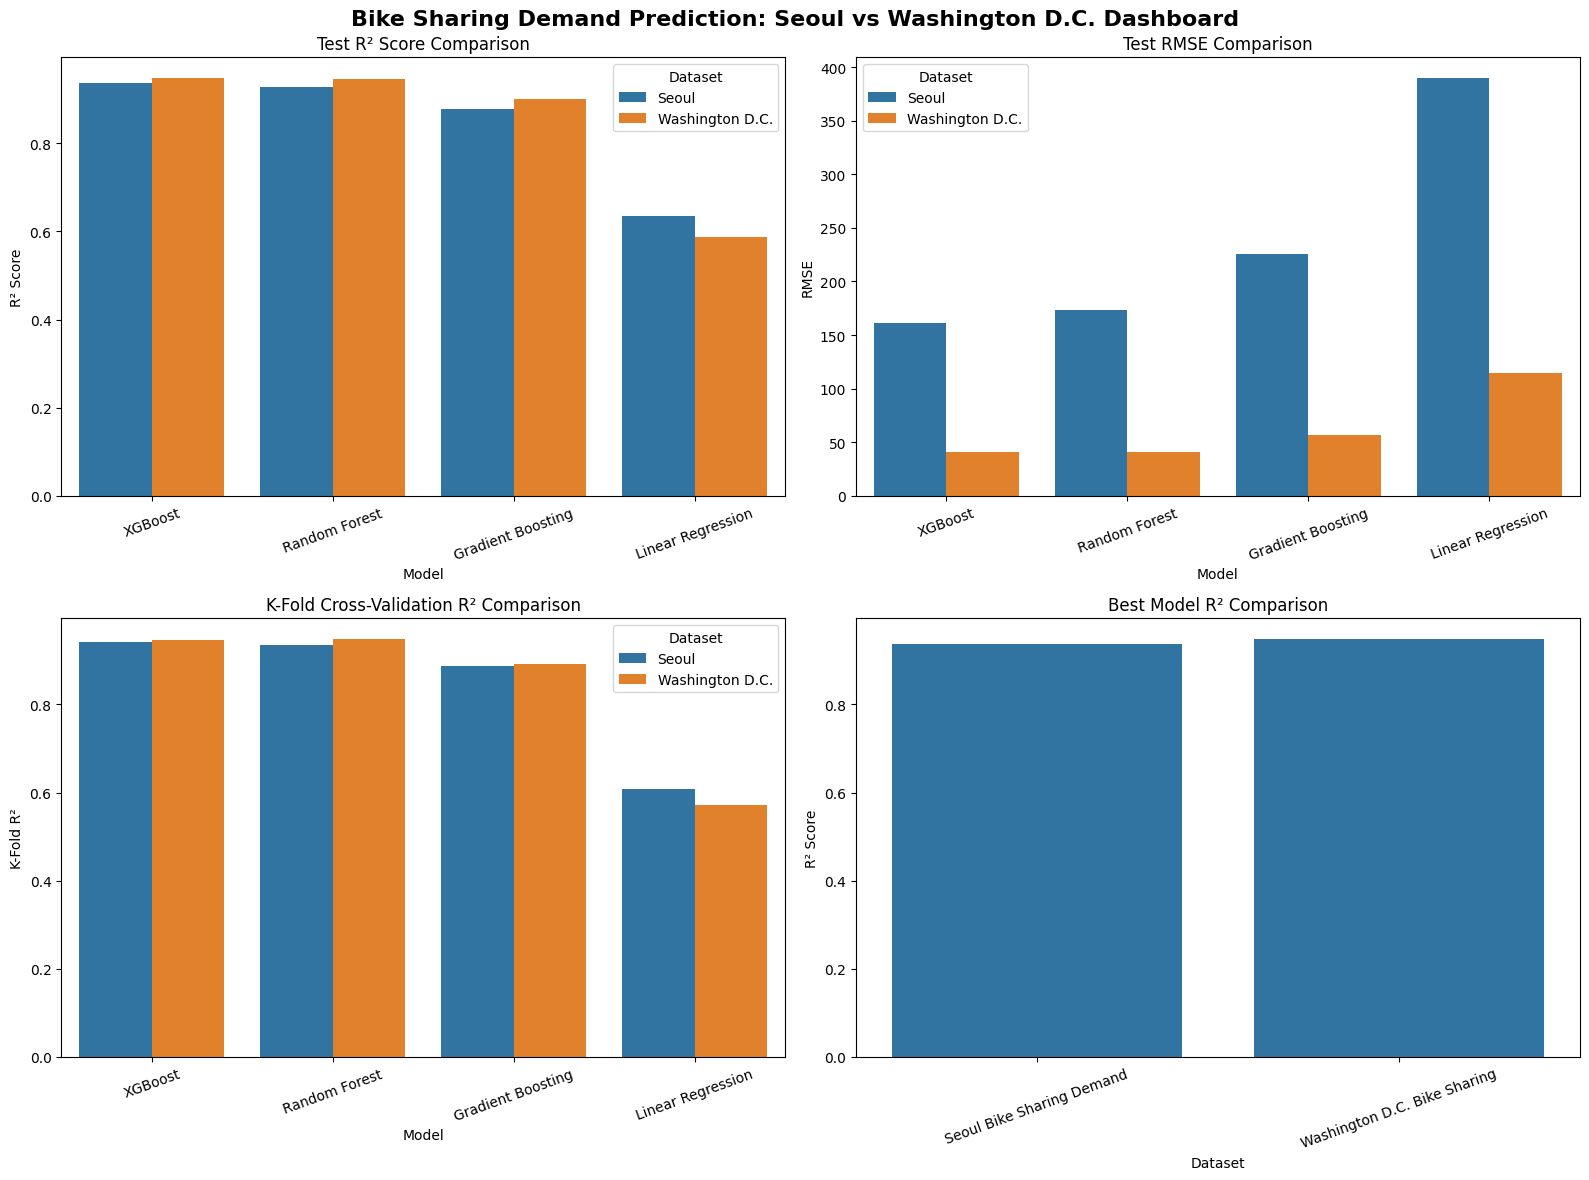

Final comparison dashboard saved as: final_seoul_vs_washington_dashboard.png


In [89]:
# ============================================================
# Final Comparative Dashboard
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ------------------------------------------------------------
# Plot 1: Test R2 Comparison
# ------------------------------------------------------------
sns.barplot(
    data=combined_test_results,
    x="Model",
    y="R2 Score",
    hue="Dataset",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Test R² Score Comparison")
axes[0, 0].set_xlabel("Model")
axes[0, 0].set_ylabel("R² Score")
axes[0, 0].tick_params(axis="x", rotation=20)

# ------------------------------------------------------------
# Plot 2: Test RMSE Comparison
# ------------------------------------------------------------
sns.barplot(
    data=combined_test_results,
    x="Model",
    y="RMSE",
    hue="Dataset",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Test RMSE Comparison")
axes[0, 1].set_xlabel("Model")
axes[0, 1].set_ylabel("RMSE")
axes[0, 1].tick_params(axis="x", rotation=20)

# ------------------------------------------------------------
# Plot 3: K-Fold R2 Comparison
# ------------------------------------------------------------
sns.barplot(
    data=combined_cv_results,
    x="Model",
    y="KFold_R2",
    hue="Dataset",
    ax=axes[1, 0]
)

axes[1, 0].set_title("K-Fold Cross-Validation R² Comparison")
axes[1, 0].set_xlabel("Model")
axes[1, 0].set_ylabel("K-Fold R²")
axes[1, 0].tick_params(axis="x", rotation=20)

# ------------------------------------------------------------
# Plot 4: Best Model R2 Comparison
# ------------------------------------------------------------
sns.barplot(
    data=dataset_comparison_df,
    x="Dataset",
    y="R2 Score",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Best Model R² Comparison")
axes[1, 1].set_xlabel("Dataset")
axes[1, 1].set_ylabel("R² Score")
axes[1, 1].tick_params(axis="x", rotation=20)

# Main dashboard title
fig.suptitle(
    "Bike Sharing Demand Prediction: Seoul vs Washington D.C. Dashboard",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("final_seoul_vs_washington_dashboard.png", dpi=300)
plt.show()

print("Final comparison dashboard saved as: final_seoul_vs_washington_dashboard.png")